In [1]:
# Script para filtrar aquellos pixeles sin ningun cambio

import pandas as pd
import numpy as np
import os
import math
from pandas.core.computation.check import NUMEXPR_INSTALLED
from scipy.signal import argrelextrema


In [2]:

import seaborn as sns
import matplotlib.pyplot as plt



In [3]:
import geopandas as gpd

In [ ]:
join=pd.read_csv('C:\\Users\\giambelluca.144055\\OneDrive\\Incendios\\Organizacion\\NBR_con_COEF\\Catalunia_coef_mag.csv')

In [ ]:
# NO, viejo

# join_nav=pd.read_csv('C:\\Users\\giambelluca.144055\\OneDrive\\Incendios\\Organizacion\\Resultados\\Unido_Tasa5y20\\Tasa_post_normalizado_30012025\\Navarra_Recuperando_20_30012025_cambio.csv')
# join_cat=pd.read_csv('C:\\Users\\giambelluca.144055\\OneDrive\\Incendios\\Organizacion\\Resultados\\Unido_Tasa5y20\\Tasa_post_normalizado_30012025\\Catalunia_Recuperando_20_30012025_cambio.csv')
# join_val=pd.read_csv('C:\\Users\\giambelluca.144055\\OneDrive\\Incendios\\Organizacion\\Resultados\\Unido_Tasa5y20\\Tasa_post_normalizado_30012025\\Valencia_Recuperando_20_30012025_cambio.csv')
# join_nav=join_nav[['Row','ID']]
# join_val=join_val[['Row','ID']]
# join_cat=join_cat[['Row','ID']]
# CCAA=pd.concat([join_nav,join_val,join_cat])

## Seleccionar solo los puntos sin segunda ruptura negativa, luego del incendio

In [ ]:
F1=join.loc[((join.F_1==join.FECHA)&(join.F_2>=2023))&((join.F_1==join.FECHA)&(join.mag2>=0)&(join.mag3>=0)&(join.mag4>=0)&(join.mag5>=0)&(join.mag6>=0))]
F2=join.loc[((join.F_2==join.FECHA)&(join.F_3>=2023))&((join.F_2==join.FECHA)&(join.mag3>=0)&(join.mag4>=0)&(join.mag5>=0)&(join.mag6>=0))]
F3=join.loc[((join.F_3==join.FECHA)&(join.F_4>=2023))&((join.F_3==join.FECHA)&(join.mag4>=0)&(join.mag5>=0)&(join.mag6>=0))]
F4=join.loc[((join.F_4==join.FECHA)&(join.F_5>=2023))&((join.F_4==join.FECHA)&(join.mag5>=0)&(join.mag6>=0))]
F5=join.loc[(join.F_5==join.FECHA)&(join.F_6>=2023)]

In [ ]:
juntos=pd.concat([F1,F2,F3,F4,F5])
juntos=juntos.drop_duplicates()
len(juntos)

In [ ]:
Nav=juntos

In [ ]:
Val=juntos

In [ ]:
Cat=juntos

In [ ]:
len(Nav)+len(Val)+len(Cat)

In [ ]:
Nav=Nav[['Row','ID', 'FECHA','longitude', 'latitude', 'geometry']]
Val=Val[['Row','ID', 'FECHA','longitude', 'latitude', 'geometry']]
Cat=Cat[['Row','ID', 'FECHA','longitude', 'latitude', 'geometry']]

In [ ]:
concatenados=pd.concat([Nav,Val,Cat])
concatenados

In [ ]:
concatenados.groupby('FECHA')['ID'].count()

In [ ]:
from shapely.geometry import Point

In [ ]:
geometry = [Point(xy) for xy in zip(concatenados['longitude'], concatenados['latitude'])]
gdf = gpd.GeoDataFrame(concatenados, geometry=geometry, crs="EPSG:4326") # EPSG:4326 es el sistema de coordenadas WGS 84

# 4. Exportar a shapefile
gdf.to_file(r"C:\Users\giambelluca.144055\OneDrive\Doctorado\Articulos\Wildfire\Puntos\Puntos_no_negativos\Puntos_sin_magneg.shp")

# Juntos todos los puntos

In [ ]:
juntos=gpd.read_file(r"C:\Users\giambelluca.144055\OneDrive\Doctorado\Articulos\Wildfire\Puntos\Puntos_no_negativos\Puntos_sin_magneg.shp")
juntos

In [ ]:
os.chdir(r'F:\NBR_article\Usar')
os.listdir()

In [ ]:
# archivos=os.listdir()
archivos=list(os.listdir())

In [ ]:
df=pd.DataFrame(columns=['Row','ID','FECHA','NBR_mean','latitude','longitude'])
df
for i in range (len(archivos)):
    prueba=pd.read_csv(archivos[i])
    # print(len(prueba),i)
    # print(prueba.columns, i)
    prueba=prueba[['Row','ID','FECHA','NBR_mean','latitude','longitude']]
    df=pd.concat([df,prueba])

df

In [ ]:
df=df.loc[df.NBR_mean>=0.4]
len(df)

In [ ]:
df.to_csv(r'F:\NBR_article\Puntos_11\Puntos_NBR_mayor_04.csv')

In [ ]:
Nav=pd.read_csv('C:\\Users\\giambelluca.144055\\OneDrive\\Incendios\\Organizacion\\NBR_con_COEF\\Navarra_coef_mag.csv')
Val=pd.read_csv('C:\\Users\\giambelluca.144055\\OneDrive\\Incendios\\Organizacion\\NBR_con_COEF\\Valencia_coef_mag.csv')
Cat=pd.read_csv('C:\\Users\\giambelluca.144055\\OneDrive\\Incendios\\Organizacion\\NBR_con_COEF\\Catalunia_coef_mag.csv')

In [ ]:
Nav=Nav[['Row','ID','Coef_1_1','Coef_1_2', 'Coef_1_3', 'Coef_1_4', 'Coef_1_5', 'Coef_1_6', 'Coef_1_7','Coef_1_8', 'Coef_2_1', 'Coef_2_2', 'Coef_2_3', 'Coef_2_4', 'Coef_2_5',
       'Coef_2_6', 'Coef_2_7', 'Coef_2_8', 'Coef_3_1', 'Coef_3_2', 'Coef_3_3', 'Coef_3_4', 'Coef_3_5', 'Coef_3_6', 'Coef_3_7', 'Coef_3_8', 'Coef_4_1','Coef_4_2', 'Coef_4_3', 'Coef_4_4', 'Coef_4_5', 'Coef_4_6', 'Coef_4_7',
       'Coef_4_8', 'Coef_5_1', 'Coef_5_2', 'Coef_5_3', 'Coef_5_4', 'Coef_5_5','Coef_5_6', 'Coef_5_7', 'Coef_5_8', 'Coef_6_1', 'Coef_6_2', 'Coef_6_3','Coef_6_4', 'Coef_6_5', 'Coef_6_6', 'Coef_6_7', 'Coef_6_8', 't1', 't2',
       't3', 't4', 't5', 't6', 'Ts1', 'Ts2', 'Ts3', 'Ts4', 'Ts5', 'Ts6','mag1', 'mag2', 'mag3', 'mag4', 'mag5', 'mag6', 'F_1', 'F_2', 'F_3','F_4', 'F_5', 'F_6' ]]
Nav

In [ ]:
Val=Val[['Row','ID','Coef_1_1','Coef_1_2', 'Coef_1_3', 'Coef_1_4', 'Coef_1_5', 'Coef_1_6', 'Coef_1_7','Coef_1_8', 'Coef_2_1', 'Coef_2_2', 'Coef_2_3', 'Coef_2_4', 'Coef_2_5',
       'Coef_2_6', 'Coef_2_7', 'Coef_2_8', 'Coef_3_1', 'Coef_3_2', 'Coef_3_3', 'Coef_3_4', 'Coef_3_5', 'Coef_3_6', 'Coef_3_7', 'Coef_3_8', 'Coef_4_1','Coef_4_2', 'Coef_4_3', 'Coef_4_4', 'Coef_4_5', 'Coef_4_6', 'Coef_4_7',
       'Coef_4_8', 'Coef_5_1', 'Coef_5_2', 'Coef_5_3', 'Coef_5_4', 'Coef_5_5','Coef_5_6', 'Coef_5_7', 'Coef_5_8', 'Coef_6_1', 'Coef_6_2', 'Coef_6_3','Coef_6_4', 'Coef_6_5', 'Coef_6_6', 'Coef_6_7', 'Coef_6_8', 't1', 't2',
       't3', 't4', 't5', 't6', 'Ts1', 'Ts2', 'Ts3', 'Ts4', 'Ts5', 'Ts6','mag1', 'mag2', 'mag3', 'mag4', 'mag5', 'mag6', 'F_1', 'F_2', 'F_3','F_4', 'F_5', 'F_6' ]]

In [ ]:
Cat=Cat[['Row','ID','Coef_1_1','Coef_1_2', 'Coef_1_3', 'Coef_1_4', 'Coef_1_5', 'Coef_1_6', 'Coef_1_7','Coef_1_8', 'Coef_2_1', 'Coef_2_2', 'Coef_2_3', 'Coef_2_4', 'Coef_2_5',
       'Coef_2_6', 'Coef_2_7', 'Coef_2_8', 'Coef_3_1', 'Coef_3_2', 'Coef_3_3', 'Coef_3_4', 'Coef_3_5', 'Coef_3_6', 'Coef_3_7', 'Coef_3_8', 'Coef_4_1','Coef_4_2', 'Coef_4_3', 'Coef_4_4', 'Coef_4_5', 'Coef_4_6', 'Coef_4_7',
       'Coef_4_8', 'Coef_5_1', 'Coef_5_2', 'Coef_5_3', 'Coef_5_4', 'Coef_5_5','Coef_5_6', 'Coef_5_7', 'Coef_5_8', 'Coef_6_1', 'Coef_6_2', 'Coef_6_3','Coef_6_4', 'Coef_6_5', 'Coef_6_6', 'Coef_6_7', 'Coef_6_8', 't1', 't2',
       't3', 't4', 't5', 't6', 'Ts1', 'Ts2', 'Ts3', 'Ts4', 'Ts5', 'Ts6','mag1', 'mag2', 'mag3', 'mag4', 'mag5', 'mag6', 'F_1', 'F_2', 'F_3','F_4', 'F_5', 'F_6' ]]

In [ ]:
coef=pd.concat([Nav,Val,Cat])

In [ ]:
juntos=pd.merge(df,coef,on=['Row','ID'])
juntos

In [ ]:
juntos=juntos.dropna()
len(juntos)

# Tasas

In [ ]:
# CCDC

# Detection of the peak before the disturbance
def detect_peaks(valores,x_s,x_f, min_height=0.01):
    principio=int(x_s.min())

    fin=int(x_f.min())
    x=fin-principio
    if x<1:
        peaks = argrelextrema(valores, np.greater, order=4)[0]
    else:
        dist=((371/x)/2)-2
        distance=int(dist)
        # print(distance)
        peaks = argrelextrema(valores, np.greater, order=distance)[0]
    return [peak for peak in peaks if valores[peak] >= min_height]

def detect_peaks_last(valores,min_height=0.01):

    peaks = argrelextrema(valores, np.greater, order=4)[0]
    
    return [peak for peak in peaks if valores[peak] >= min_height]


# Calculate coefficients to recreate the CCDC fit
def coef(select):
    # Before
    coefficients_1=np.array([select['Coef_1_1'],select['Coef_1_2'],select['Coef_1_3'],select['Coef_1_4'],select['Coef_1_5'],select['Coef_1_6'],select['Coef_1_7'],select['Coef_1_8']])
    # After
    coefficients_2=np.array([select['Coef_2_1'],select['Coef_2_2'],select['Coef_2_3'],select['Coef_2_4'],select['Coef_2_5'],select['Coef_2_6'],select['Coef_2_7'],select['Coef_2_8']])

    # print('Coeficientes: ',coefficients_1[1])
    return coefficients_1,coefficients_2

# Consider the start date and split the time serie in order to have the same frequency in the time serie.
def x_axes(select):
    # Before
    x_1 = np.linspace(select['Ts1'], select['t1'], int((1 - 0) /0.0027) + 1)
    # After
    x_2=np.linspace(select['Ts2'], select['t2'], int((1 - 0) / 0.0027) + 1)

    # print('Eje x: ',x_1)
    return x_1,x_2

#Calculate the coefficients based on the function developed before and fit the model after and before the fire.

def trigger(data):
    coefficients_1,coefficients_2=coef(data)
    x_1,x_2=x_axes(data)
    y_pred=fit_function(x_1,coefficients_1)
    y_after=fit_function(x_2,coefficients_2)
    # print('Y predicho: ',y_pred)
    return y_pred,y_after,x_1,x_2

# Fit the function considering the different coefficients
def reemplazar_valores(array):
    return np.array([1 if abs(x) > 1 else x for x in array])



def fit_function(x, coefficients):
    # Extract individual coefficients
    intercept = coefficients[0]
    slope = coefficients[1]
    sin_coeff = coefficients[2]
    cos_coeff = coefficients[3]
    sin2_coeff = coefficients[4]
    cos2_coeff = coefficients[5]
    sin3_coeff = coefficients[6]
    cos3_coeff = coefficients[7]

    # Calculate the predicted values using the coefficients and input data. Formula based on formula used in Google Earth Engine
    pi=math.pi
    Pi2=(2*pi)
    #Pi2=pi
    
    y_pred=intercept + slope * x  + sin_coeff * np.sin(x*Pi2) + cos_coeff * np.cos(x*Pi2) + sin2_coeff * np.sin(2 *x*Pi2) + cos2_coeff * np.cos(2 *x*Pi2)+ sin3_coeff * np.sin(3 *x*Pi2) + cos3_coeff * np.cos(3 *x*Pi2)

    y_pred=reemplazar_valores(y_pred)
    #y_pred=intercept + slope * x  + sin_coeff *x* np.sin(Pi2) + cos_coeff *x* np.cos(Pi2) + sin2_coeff *x* np.sin(2 *Pi2) + cos2_coeff *x* np.cos(2 *Pi2)+ sin3_coeff *x* np.sin(3 *Pi2) + cos3_coeff *x* np.cos(3 *Pi2)
    
    return y_pred



def coef_sig(select):
    # Before
    coefficients_3=np.array([select['Coef_3_1'],select['Coef_3_2'],select['Coef_3_3'],select['Coef_3_4'],select['Coef_3_5'],select['Coef_3_6'],select['Coef_3_7'],select['Coef_3_8']])
    # After
    coefficients_4=np.array([select['Coef_4_1'],select['Coef_4_2'],select['Coef_4_3'],select['Coef_4_4'],select['Coef_4_5'],select['Coef_4_6'],select['Coef_4_7'],select['Coef_4_8']])
    
    coefficients_5=np.array([select['Coef_5_1'],select['Coef_5_2'],select['Coef_5_3'],select['Coef_5_4'],select['Coef_5_5'],select['Coef_5_6'],select['Coef_5_7'],select['Coef_5_8']])
    
    coefficients_6=np.array([select['Coef_6_1'],select['Coef_6_2'],select['Coef_6_3'],select['Coef_6_4'],select['Coef_6_5'],select['Coef_6_6'],select['Coef_6_7'],select['Coef_6_8']])
    

    return coefficients_3,coefficients_4,coefficients_5,coefficients_6

# Consider the start date and split the time serie in order to have the same frequency in the time serie.
def x_axes_sig(select):
    # Before
    x_3 = np.linspace(select['Ts3'], select['t3'], int((1 - 0) /0.0027) + 1)
    # After
    x_4=np.linspace(select['Ts4'], select['t4'], int((1 - 0) / 0.0027) + 1)
    
    x_5=np.linspace(select['Ts5'], select['t5'], int((1 - 0) / 0.0027) + 1)
    
    x_6=np.linspace(select['Ts6'], select['t6'], int((1 - 0) / 0.0027) + 1)

    return x_3,x_4,x_5,x_6

#Calculate the coefficients based on the function developed before and fit the model after and before the fire.

def trigger_sig(data):
    coefficients_3,coefficients_4,coefficients_5,coefficients_6=coef_sig(data)
    x_3,x_4,x_5,x_6=x_axes_sig(data)
    y_3=fit_function(x_3,coefficients_3)
    y_4=fit_function(x_4,coefficients_4)
    y_5=fit_function(x_5,coefficients_5)
    y_6=fit_function(x_6,coefficients_6)

    return y_3,y_4,y_5,y_6,x_3,x_4,x_5,x_6

In [ ]:
prueba=juntos

In [ ]:
# Tasas
nombres_columnas=[1983,1984,1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004,2005, 2006, 2007, 2008, 2009, 2010, 2011,
        2012, 2013, 2014, 2015, 2016, 2018, 2019, 2020, 2021, 2022, 2023,'Row']
# Creation of other dataset to store the recovery information
df_recovery_1=pd.DataFrame(columns=nombres_columnas)
rows=list(prueba.Row)
NBR_year=[]
NBR_post=[]
value_before=[]
year=[]


for i in range (len(prueba)):
    data=prueba.iloc[i]
    y_1,y_2,x_1,x_2 = trigger(data)
    y_3,y_4,y_5,y_6,x_3,x_4,x_5,x_6=trigger_sig(data)
    pic_ind_1 = detect_peaks(y_1,x_1,x_2) #El resultado son los indices con pico
    pic_ind_2 = detect_peaks(y_2,x_2,x_3)
    pic_ind_3 = detect_peaks(y_3,x_3,x_4) #El resultado son los indices con pico
    pic_ind_4 = detect_peaks(y_4,x_4,x_5)
    pic_ind_5 = detect_peaks(y_5,x_5,x_6) #El resultado son los indices con pico
    pic_ind_6 = detect_peaks_last(y_6)

    x_pic_3=x_3[pic_ind_3]
    x_pic_4=x_4[pic_ind_4]
    x_pic_5=x_5[pic_ind_5]
    x_pic_6=x_6[pic_ind_6]


    #Sustitution of y variable and calculate the NBR value
    value_pred_1=y_1[pic_ind_1] # Tengo los valores de cada pico
    value_pred_2=y_2[pic_ind_2]
 
    #Sustitution of y variable and calculate the NBR value
    value_pred_3=y_3[pic_ind_3] # Tengo los valores de cada pico
    value_pred_4=y_4[pic_ind_4]
    value_pred_5=y_5[pic_ind_5] # Tengo los valores de cada pico
    value_pred_6=y_6[pic_ind_6]
    
    #Obtain the x (time serie) with the maximum value of NBR
    x_pic_1=x_1[pic_ind_1]
    x_pic_2=x_2[pic_ind_2]

    
    df1=pd.DataFrame({'Year':x_pic_1,'NBR_year':value_pred_1})
    df2=pd.DataFrame({'Year':x_pic_2,'NBR_year':value_pred_2})
    df3=pd.DataFrame({'Year':x_pic_3,'NBR_year':value_pred_3})
    df4=pd.DataFrame({'Year':x_pic_4,'NBR_year':value_pred_4})
    df5=pd.DataFrame({'Year':x_pic_5,'NBR_year':value_pred_5})
    df6=pd.DataFrame({'Year':x_pic_6,'NBR_year':value_pred_6})
    
    df=pd.concat([df1,df2,df3,df4,df5,df6])
    df['Year']=df['Year'].astype(int)
    df=df.loc[(df.Year>1982)]#&(df.Year!=2004)]
    df=df.groupby('Year')[['NBR_year']].max()
    df=df.pivot_table(values='NBR_year', index='Year', aggfunc='first').T
    df['Row']=str(data.Row)
    df['ID']=str(data.ID)

    df_recovery_1=pd.concat([df_recovery_1,df])

In [ ]:
df_recovery_1.to_csv(r'F:\NBR_article\Puntos_11\Puntos_NBR_mayor_04_tasas_ID.csv')


In [ ]:
join=pd.merge(juntos,df_recovery_1,on=['Row','ID'])


In [ ]:
len(join)

In [ ]:
for i in range (1984,2004,1):
    print(i)
    post=i+1
    cinco=i+5
    join.loc[(join.FECHA==i),['Rate_5']]=(join[cinco]-join[post])/5
    veinte=i+20
    join.loc[(join.FECHA==i),['Rate_20']]=(join[veinte]-join[post])/20
    
    

In [ ]:
tasas=join[['Row','ID','Rate_5','Rate_20']]
print(len(tasas))
tasas=tasas.dropna()
print(len(tasas))

In [ ]:
tasas=tasas.drop_duplicates()

In [ ]:
len(tasas)

In [ ]:
tasas

In [ ]:
juntos

In [ ]:
NBR_mayor=pd.merge(tasas,juntos,on=['Row','ID'])
NBR_mayor

In [ ]:
geometry = [Point(xy) for xy in zip(NBR_mayor['longitude'], NBR_mayor['latitude'])]
gdf = gpd.GeoDataFrame(NBR_mayor, geometry=geometry, crs="EPSG:4326") # EPSG:4326 es el sistema de coordenadas WGS 84

# 4. Exportar a shapefile
gdf.to_file(r"C:\Users\giambelluca.144055\OneDrive\Doctorado\Articulos\Wildfire\Puntos\Puntos_no_negativos\Puntos_NBR_Mayores_04.gpkg")

In [ ]:
df_recovery

# Leer archivo luego de reemuestreo a 100 m con Spatial Eco

In [ ]:
remuestreo=pd.read_csv(r'C:\Users\giambelluca.144055\OneDrive\Doctorado\Articulos\Wildfire\Puntos\Filtro100_NBR04\Puntos_arti_NBR_04.csv')

In [ ]:
remuestreo.columns

In [ ]:
df_recovery=pd.read_csv(r'F:\NBR_article\Puntos_11\Puntos_NBR_mayor_04_tasas_ID.csv')

In [ ]:
df_recovery.columns

In [ ]:
join=pd.merge(remuestreo,df_recovery,on=['Row','ID'])
len(join)

In [ ]:
for i in range (1986,2004,1):
    pre1=str(i-2)
    pre2=str(i-1)
    post=str(i+1)
    
    join.loc[(join.FECHA==i),['NBR_pre_fire']]=(join[pre1]+join[pre2])/2
    join.loc[(join.FECHA==i),['NBR_post_fire']]=(join[post])

In [ ]:
join=join.loc[join.NBR_pre_fire>=0.4]

In [ ]:
len(join)

# Union de capas

In [ ]:
def CCAA(num):
    return str(num)[-1:]

join['CCAA']=join['ID'].apply(CCAA)

In [ ]:
Tasas=join

In [ ]:
Nav=join.loc[(join.CCAA=='C')]
len(Nav)

# CCAA Clima

In [ ]:
def fechas(num):
    return str(num)[:7]


def year(num):
    return str(num)[:4]

def month(num):
    return str(num)[5:]

## Precipitacion

In [ ]:
import csv

In [ ]:
# pip install dask

In [ ]:
import dask

In [ ]:
# os.chdir(r'C:\Users\giambelluca.144055\OneDrive\Doctorado\3_PGS\3PGS\Rain')
# os.chdir(r'F:\Clima')
os.chdir(r'E:\Catalunia_s_int\Rain')
# print(os.listdir())
# clima_prec=pd.read_csv('Navarra_prec.csv')
# clima_prec=pd.read_csv('Valencia_prec.csv')
clima_prec=pd.read_csv('Catalunia_rain.csv', 
                        usecols=['Date', 'Row', 'Rain'])

# clima_prec=clima_prec[['Date', 'Latitude', 'Longitude', 'Row', 'Prec', 'row','column']]

In [ ]:
clima_prec

In [ ]:
variable=pd.merge(Nav,clima_prec,on='Row')

In [ ]:
del clima_prec

In [ ]:
len(variable)

In [ ]:
variable['Date']=variable['Date'].apply(fechas)
variable['Year']=variable['Date'].apply(year)
variable['Month']=variable['Date'].apply(month)
variable

In [ ]:
variable=variable.loc[(variable.Month=='05')|(variable.Month=='06')|(variable.Month=='07')|(variable.Month=='08')|(variable.Month=='09')|(variable.Month=='10')]

In [ ]:
join=variable

In [ ]:
# join=pd.merge(variable,Nav,on='Row')
join['Year']=join['Year'].astype(int)
join['FECHA']=join['FECHA'].astype(int)

In [ ]:
filtered_5year=join.loc[((join.Year>=(join.FECHA))&(join.Year<(join.FECHA+5)))]
filtered_20year=join.loc[(join.Year>=(join.FECHA))&(join.Year<(join.FECHA+20))]

resultados_V_5 = filtered_5year.groupby('Row')['Rain'].sum().reset_index()
resultados_V_5.columns=['Row','Prec_5']
resultados_V_20 = filtered_20year.groupby('Row')['Rain'].sum().reset_index()
resultados_V_20.columns=['Row','Prec_20']

join_prec=pd.merge(resultados_V_5,resultados_V_20,on='Row')
join_prec

In [ ]:
# join_prec.to_csv(r'C:\Users\giambelluca.144055\OneDrive\Doctorado\Articulos\Wildfire\Puntos\Filtro100_NBR04\Prec_Valencia.csv')
join_prec.to_csv(r'C:\Users\giambelluca.144055\OneDrive\Doctorado\Articulos\Wildfire\Puntos\Filtro100_NBR04\Prec_Catalunia.csv')

## Temperatura

In [206]:
# os.chdir(r'C:\Users\giambelluca.144055\OneDrive\Doctorado\3_PGS\3PGS\Tmax')
os.chdir(r'F:\Clima')
os.chdir(r'F:\catalunia\Antes_de_interpolacion\Tmax')
# clima_Tmax=pd.read_csv('Navarra_Tmax.csv')
# clima_Tmax=pd.read_csv('Valencia_Tmax.csv')

clima_tx=pd.read_csv('Catalunia_tx.csv', 
                        usecols=['Date', 'Row', 'Tamx'])
clima_tx.columns=['Date', 'Row', 'Tmax']
# clima_tx=clima_Tmax[['Date', 'Latitude', 'Longitude', 'Row', 'Tmax', 'row','column']]

In [207]:
clima_tx

,Date,Row,Tmax
0,1985_01_tx.tif,[7884 2071],9.902580
1,1985_02_tx.tif,[7884 2071],16.177143
2,1985_03_tx.tif,[7884 2071],16.557741
3,1985_04_tx.tif,[7884 2071],21.021000
4,1985_05_tx.tif,[7884 2071],20.859356
...,...,...,...
378581575,2023_08_tx.tif,[ 4730 10095],31.280966
378581576,2023_09_tx.tif,[ 4730 10095],28.232332
378581577,2023_10_tx.tif,[ 4730 10095],25.449678
378581578,2023_11_tx.tif,[ 4730 10095],19.422667


In [ ]:
print(len(clima_tx))
clima_tx=pd.merge(Nav,clima_tx,on='Row')
len(clima_tx)

In [ ]:
clima_tx['Year']=clima_tx['Date'].apply(year)
clima_tx['Month']=clima_tx['Date'].apply(month)
clima_tx

In [ ]:
clima_tx=clima_tx.loc[(clima_tx.Month=='05_tx.tif')|(clima_tx.Month=='06_tx.tif')|(clima_tx.Month=='07_tx.tif')|(clima_tx.Month=='08_tx.tif')|(clima_tx.Month=='09_tx.tif')|(clima_tx.Month=='10_tx.tif')]

In [ ]:
join=clima_tx
join

In [ ]:
del clima_tx

In [ ]:
# join=pd.merge(clima_tx,Nav,on='Row')
join['Year']=join['Year'].astype(int)
join['FECHA']=join['FECHA'].astype(int)
len(join)

In [ ]:
filtered_5year=join.loc[((join.Year>=(join.FECHA))&(join.Year<(join.FECHA+5)))]
filtered_20year=join.loc[(join.Year>=(join.FECHA))&(join.Year<(join.FECHA+20))]

resultados_V_5 = filtered_5year.groupby('Row')['Tmax'].mean().reset_index()
resultados_V_5.columns=['Row','Tmax_5']
resultados_V_20 = filtered_20year.groupby('Row')['Tmax'].mean().reset_index()
resultados_V_20.columns=['Row','Tmax_20']

join_tmax=pd.merge(resultados_V_5,resultados_V_20,on='Row')
join_tmax

In [ ]:
# join_tmax.to_csv(r'C:\Users\giambelluca.144055\OneDrive\Doctorado\Articulos\Wildfire\Puntos\Filtro100_NBR04\Tmax_Valencia.csv')
join_tmax.to_csv(r'C:\Users\giambelluca.144055\OneDrive\Doctorado\Articulos\Wildfire\Puntos\Filtro100_NBR04\Tmax_Catalunia.csv')

## Tmin

In [ ]:
# os.chdir(r'C:\Users\giambelluca.144055\OneDrive\Doctorado\3_PGS\3PGS\Tmin')
# os.chdir(r'E:\Clima')
os.chdir(r'E:\Catalunia_s_int\Tmin')
# clima_Tmin=pd.read_csv('Navarra_Tmin.csv')
# clima_Tmin=pd.read_csv('Valencia_Tmin.csv')
# clima_tmin=clima_Tmin[['Date', 'Latitude', 'Longitude', 'Row', 'Tmin', 'row','column']]
clima_tmin=pd.read_csv('Catalunia_tn.csv', 
                        usecols=['Date', 'Row', 'Tmin'])
clima_tmin=pd.merge(Nav,clima_tmin,on='Row')

In [ ]:
len(clima_tmin)

In [ ]:
clima_tmin['Year']=clima_tmin['Date'].apply(year)
clima_tmin['Month']=clima_tmin['Date'].apply(month)
clima_tmin

In [ ]:
clima_tmin=clima_tmin.loc[(clima_tmin.Month=='05_tn.tif')|(clima_tmin.Month=='06_tn.tif')|(clima_tmin.Month=='07_tn.tif')|(clima_tmin.Month=='08_tn.tif')|(clima_tmin.Month=='09_tn.tif')|(clima_tmin.Month=='10_tn.tif')]

In [ ]:
join=clima_tmin
del clima_tmin

In [ ]:
# join=pd.merge(clima_tmin,Nav,on='Row')
join['Year']=join['Year'].astype(int)
join['FECHA']=join['FECHA'].astype(int)
len(join)

In [ ]:
filtered_5year=join.loc[((join.Year>=(join.FECHA))&(join.Year<(join.FECHA+5)))]
filtered_20year=join.loc[(join.Year>=(join.FECHA))&(join.Year<(join.FECHA+20))]

resultados_V_5 = filtered_5year.groupby('Row')['Tmin'].mean().reset_index()
resultados_V_5.columns=['Row','Tmin_5']
resultados_V_20 = filtered_20year.groupby('Row')['Tmin'].mean().reset_index()
resultados_V_20.columns=['Row','Tmin_20']

join_tmin=pd.merge(resultados_V_5,resultados_V_20,on='Row')
join_tmin

In [ ]:
# join_tmin.to_csv(r'C:\Users\giambelluca.144055\OneDrive\Doctorado\Articulos\Wildfire\Puntos\Filtro100_NBR04\Tmin_Valencia.csv')
# join_tmin.to_csv(r'C:\Users\giambelluca.144055\OneDrive\Doctorado\Articulos\Wildfire\Puntos\Filtro100_NBR04\Tmin_Catalunia.csv')

## SPEI

In [196]:
os.chdir('C:\\Users\\giambelluca.144055\\OneDrive\\SPEI\\SEPI_Nav')
# os.chdir('C:\\Users\\giambelluca.144055\\OneDrive\\SPEI\\SEPI_Val')
# os.chdir('C:\\Users\\giambelluca.144055\\OneDrive\\SPEI\\SEPI_Cat')
# os.listdir()
spei=pd.read_csv('Navarra_spei.csv')
# spei=pd.read_csv('Valencia_spei.csv')
# spei=pd.read_csv('Catalunia_spei.csv')
# SPEI=pd.merge(spei,Nav,on='Row')


In [197]:
spei

,Unnamed: 0,Date,Latitude,Longitude,Row,spei6,row,column,Year
0,0,1985_12_spei.tif,42.703427,-1.824879,[4811 4360],0.273763,5,4,1985
1,1,1986_12_spei.tif,42.703427,-1.824879,[4811 4360],0.203857,5,4,1986
2,2,1987_12_spei.tif,42.703427,-1.824879,[4811 4360],0.099121,5,4,1987
3,3,1988_12_spei.tif,42.703427,-1.824879,[4811 4360],0.061768,5,4,1988
4,4,1989_12_spei.tif,42.703427,-1.824879,[4811 4360],-0.250244,5,4,1989
...,...,...,...,...,...,...,...,...,...
585175,585175,2010_12_spei.tif,42.402940,-1.177553,[5926 6762],0.048828,7,9,2010
585176,585176,2011_12_spei.tif,42.402940,-1.177553,[5926 6762],-0.486410,7,9,2011
585177,585177,2012_12_spei.tif,42.402940,-1.177553,[5926 6762],-0.907796,7,9,2012
585178,585178,2013_12_spei.tif,42.402940,-1.177553,[5926 6762],0.386882,7,9,2013


In [ ]:
SPEI

In [ ]:
SPEI['Year']=SPEI['Year'].astype(int)
SPEI['FECHA']=SPEI['FECHA'].astype(int)

filtered_5year=SPEI.loc[((SPEI.Year>=SPEI.FECHA)&(SPEI.Year<(SPEI.FECHA+5)))]
filtered_20year=SPEI.loc[(SPEI.Year>=SPEI.FECHA)&(SPEI.Year<(SPEI.FECHA+20))]

resultados_prec_5 = filtered_5year.groupby('Row')['spei6'].mean().reset_index()
resultados_prec_5.columns=['Row','SPEI6_5']
resultados_prec_20 = filtered_20year.groupby('Row')['spei6'].mean().reset_index()
resultados_prec_20.columns=['Row','SPEI6_20']

join_spei=pd.merge(resultados_prec_5,resultados_prec_20,on='Row')

# union_1=pd.merge(Nav,join_spei,on='Row')
# join_nav=pd.merge(union_1,clima_a,on='Row')

# del union_1,SPEI
join_spei

In [ ]:
join_prec=pd.read_csv(r'C:\Users\giambelluca.144055\OneDrive\Doctorado\Articulos\Wildfire\Puntos\Filtro100_NBR04\Prec_Catalunia.csv')
join_tmax=pd.read_csv(r'C:\Users\giambelluca.144055\OneDrive\Doctorado\Articulos\Wildfire\Puntos\Filtro100_NBR04\Tmax_Catalunia.csv')
join_tmin=pd.read_csv(r'C:\Users\giambelluca.144055\OneDrive\Doctorado\Articulos\Wildfire\Puntos\Filtro100_NBR04\Tmin_Catalunia.csv')

In [ ]:
join_prec

In [ ]:
Clima_NAVARRA=pd.merge(Nav,join_prec,on='Row')
Clima_NAVARRA=pd.merge(Clima_NAVARRA,join_tmax,on='Row')


In [ ]:
Clima_NAVARRA=Clima_NAVARRA[['Row','ID','Rate_5','Rate_20','FECHA','NBR_mean','latitude','longitude', 'Prec_5','Prec_20','Tmax_5','Tmax_20']]

In [ ]:
Clima_NAVARRA=pd.merge(Clima_NAVARRA,join_tmin,on='Row')

In [ ]:
Clima_NAVARRA=pd.merge(Clima_NAVARRA,join_spei,on='Row')

In [ ]:
Clima_NAVARRA=Clima_NAVARRA[['Row', 'ID', 'Rate_5', 'Rate_20', 'FECHA', 'NBR_mean', 'latitude','longitude', 'Prec_5', 'Prec_20', 'Tmax_5', 'Tmax_20','Tmin_5', 'Tmin_20', 'SPEI6_5', 'SPEI6_20']]

In [ ]:
Clima_NAVARRA=Clima_NAVARRA.drop_duplicates()
Clima_NAVARRA

In [ ]:
Clima_NAVARRA=pd.merge(Nav,Clima_NAVARRA,on='Row')

# Union Valencia, Navarra, Catalunia

In [ ]:
Clima_NAVARRA=pd.read_csv(r'C:\Users\giambelluca.144055\OneDrive\Doctorado\Articulos\Wildfire\Puntos\Filtro100_NBR04\Clima_Navarra.csv')
Clima_Valencia=pd.read_csv(r'C:\Users\giambelluca.144055\OneDrive\Doctorado\Articulos\Wildfire\Puntos\Filtro100_NBR04\Clima_Valencia.csv')
Clima_Catalunia=pd.read_csv(r'C:\Users\giambelluca.144055\OneDrive\Doctorado\Articulos\Wildfire\Puntos\Filtro100_NBR04\Clima_Catalunia.csv')

In [ ]:
Clima_Catalunia=Clima_Catalunia[['Row', 'ID_x', 'Rate_5_x', 'Rate_20_x', 'FECHA_x','NBR_mean_x', 'latitude_x', 'longitude_x','Prec_5', 'Prec_20', 'Tmax_5', 'Tmax_20',
       'Tmin_5', 'Tmin_20', 'SPEI6_5', 'SPEI6_20']]
Clima_Catalunia.columns=['Row', 'ID', 'Rate_5', 'Rate_20', 'FECHA','NBR_mean', 'latitude', 'longitude','Prec_5', 'Prec_20', 'Tmax_5', 'Tmax_20',
       'Tmin_5', 'Tmin_20', 'SPEI6_5', 'SPEI6_20']

In [ ]:
Clima_Valencia=Clima_Valencia[['Row', 'ID', 'Rate_5', 'Rate_20', 'FECHA','NBR_mean', 'latitude', 'longitude','Prec_5', 'Prec_20', 'Tmax_5', 'Tmax_20',
       'Tmin_5', 'Tmin_20', 'SPEI6_5', 'SPEI6_20']]


In [ ]:
Clima_NAVARRA=Clima_NAVARRA[['Row', 'ID', 'Rate_5', 'Rate_20', 'FECHA','NBR_mean', 'latitude', 'longitude','Prec_5', 'Prec_20', 'Tmax_5', 'Tmax_20',
       'Tmin_5', 'Tmin_20', 'SPEI6_5', 'SPEI6_20']]


In [ ]:
Nav=pd.read_csv('C:\\Users\\giambelluca.144055\\OneDrive\\Incendios\\Organizacion\\NBR_con_COEF\\Navarra_coef_mag.csv')
Val=pd.read_csv('C:\\Users\\giambelluca.144055\\OneDrive\\Incendios\\Organizacion\\NBR_con_COEF\\Valencia_coef_mag.csv')
Cat=pd.read_csv('C:\\Users\\giambelluca.144055\\OneDrive\\Incendios\\Organizacion\\NBR_con_COEF\\Catalunia_coef_mag.csv')

In [ ]:
Nav=Nav[['Row','ID','ID_forest', 'Magnitude','Severity', 'Slope',
       'Aspect', 'Face', 'TRSI', 'Height', 'North', 'East', 'CCAA', 'Especie1',
       'MFE_1985_R', 'ID', 'FECHA', 'Label', 'Range_S', 'Range_H']]

Navarra=pd.merge(Nav,Clima_NAVARRA,on=['Row'])
len(Navarra)

In [ ]:
Val=Val[['Row','ID','ID_forest', 'Magnitude','Severity', 'Slope',
       'Aspect', 'Face', 'TRSI', 'Height', 'North', 'East', 'CCAA', 'Especie1',
       'MFE_1985_R', 'ID', 'FECHA', 'Label', 'Range_S', 'Range_H']]

Valencia=pd.merge(Val,Clima_Valencia,on=['Row'])
Valencia=Valencia.drop_duplicates()
len(Valencia)

In [ ]:
Navarra=Navarra.dropna()
len(Navarra)

In [ ]:
Cat=Cat[['Row','ID','ID_forest', 'Magnitude','Severity', 'Slope',
       'Aspect', 'Face', 'TRSI', 'Height', 'North', 'East', 'CCAA', 'Especie1',
       'MFE_1985_R', 'ID', 'FECHA', 'Label', 'Range_S', 'Range_H']]

Catalunia=pd.merge(Cat,Clima_Catalunia,on=['Row'])
Catalunia=Catalunia.drop_duplicates()
Catalunia=Catalunia.dropna()
len(Catalunia)

In [ ]:
join=pd.concat([Navarra,Valencia,Catalunia])
len(join)

In [ ]:
# join.to_csv(r'C:\Users\giambelluca.144055\OneDrive\Doctorado\Articulos\Wildfire\Puntos\Filtro100_NBR04\Articulo_NBR_Clima_topo_Sev_25032025.csv')

# Modelo

In [ ]:
# NBR=join[['Row','ID','NBR_pre_fire','NBR_post_fire',]]

In [ ]:
# NBR['IDs']=NBR['Row']+NBR['ID']

In [ ]:
# join=pd.read_csv(r'C:\Users\giambelluca.144055\OneDrive\Doctorado\Articulos\Wildfire\Puntos\Filtro100_NBR04\Articulo_NBR_Clima_topo_Sev_25032025.csv')

In [ ]:
# join

In [ ]:
# join['IDs']=join['Row']+join['ID_x']

In [ ]:
# join=pd.merge(NBR,join,on=['IDs'])

In [ ]:
# join=join[['Row_x', 'ID', 'NBR_pre_fire', 'NBR_post_fire', 'IDs', 'ID_forest', 'Magnitude', 'Severity',
#        'Slope', 'Aspect', 'Face', 'TRSI', 'Height', 'North', 'East', 'CCAA',
#        'Especie1', 'MFE_1985_R','FECHA_x', 'Label','Range_S', 'Range_H', 'Rate_5', 'Rate_20', 'NBR_mean', 'latitude', 'longitude', 'Prec_5', 'Prec_20', 'Tmax_5',
#        'Tmax_20', 'Tmin_5', 'Tmin_20', 'SPEI6_5', 'SPEI6_20']]

In [ ]:
# join.columns=['Row', 'ID', 'NBR_pre_fire', 'NBR_post_fire', 'IDs', 'ID_forest',
#        'Magnitude', 'Severity', 'Slope', 'Aspect', 'Face', 'TRSI', 'Height',
#        'North', 'East', 'CCAA', 'Especie1', 'MFE_1985_R', 'FECHA', 'Label',
#        'Range_S', 'Range_H', 'Rate_5', 'Rate_20', 'NBR_mean', 'latitude',
#        'longitude', 'Prec_5', 'Prec_20', 'Tmax_5', 'Tmax_20', 'Tmin_5',
#        'Tmin_20', 'SPEI6_5', 'SPEI6_20']

In [ ]:
# df=join[['NBR_pre_fire', 'NBR_post_fire','Magnitude','Slope', 'Aspect','Height','Rate_5', 'Rate_20', 'Prec_5', 'Prec_20', 'Tmax_5', 'Tmax_20', 'Tmin_5',
#        'Tmin_20', 'SPEI6_5', 'SPEI6_20']]

In [ ]:

# import pandas as pd

# def calculate_stats(df):

#     # Seleccionar solo las columnas numéricas
#     numeric_cols = df.select_dtypes(include=['number']).columns

#     # Crear un diccionario para almacenar los resultados
#     stats = {
#         'Min': df[numeric_cols].min(),
#         'Max': df[numeric_cols].max(),
#         'Mean': df[numeric_cols].mean()
#     }

#     # Crear un DataFrame a partir del diccionario
#     stats_df = pd.DataFrame(stats)

#     return stats_df

# # Ejemplo de uso con tu DataFrame 'join'
# # Asegúrate de que 'join' esté definido correctamente antes de usar esta función.
# stats_result = calculate_stats(join)

# # Imprimir el DataFrame resultante
# print(stats_result)

In [ ]:
# join=join.drop_duplicates()
# len(join)

In [ ]:
# join=pd.read_csv(r'C:\Users\giambelluca.144055\OneDrive\Doctorado\Articulos\Wildfire\Puntos\Filtro100_NBR04\Articulo_NBR_Clima_topo_Sev_pre_post_25032025.csv')

In [ ]:
# join=join.loc[join.Prec_5>0]
# join=join.loc[(join.Magnitude>-1.5)]
# join=join.loc[join.Prec_5<5000]

# join=join.loc[join.FECHA<2001]

In [10]:
join=pd.read_csv(r'C:\Users\giambelluca.144055\OneDrive\Doctorado\Articulos\Wildfire\Puntos\Filtro100_NBR04\Articulo_NBR_spei_pre_post_27032025.csv')

In [11]:
join

,Unnamed: 0.1,Unnamed: 0,Row,ID,NBR_pre_fire,NBR_post_fire,IDs,ID_forest,Magnitude,Severity,...,latitude,longitude,Prec_5,Prec_20,Tmax_5,Tmax_20,Tmin_5,Tmin_20,SPEI6_5,SPEI6_20
0,0,0,[3693 6452],2769_C,0.619521,0.259847,[3693 6452]2769_C,2769378.0,-0.805990,High,...,42.004622,1.738914,1778.900034,7635.000118,21.076553,22.404897,11.145752,11.658660,-0.320980,-0.445321
1,2,2,[3836 5662],4186_C,0.702410,0.303376,[3836 5662]4186_C,4186124.0,-0.982603,High,...,41.966084,1.526013,1575.400035,5814.600116,22.826210,24.751893,12.476340,12.361343,-0.444222,-0.456284
2,4,4,[4775 8160],4060_C,0.751668,0.487907,[4775 8160]4060_C,4060379.0,-1.003493,High,...,41.713029,2.199211,1629.600034,6593.000115,22.326777,23.339992,12.913321,13.188058,-0.451335,-0.372742
3,5,5,[4748 8305],4060_C,0.565660,0.390595,[4748 8305]4060_C,4060379.0,-0.757767,High,...,41.720305,2.238287,1622.800019,6627.600158,22.926958,23.922328,13.347965,13.487526,-0.451335,-0.372742
4,6,6,[4601 9743],510_C,0.681981,0.504946,[4601 9743]510_C,51046.0,-0.905864,High,...,41.759921,2.625820,1310.400029,5589.400105,26.077072,26.462798,14.569105,14.711922,-0.442969,-0.417554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13038,14050,14095,[4891 3876],10680_V,0.544578,0.358693,[4891 3876]10680_V,1068024.0,-0.767129,High,...,39.681867,-0.955494,731.800018,3503.500061,26.584367,27.149373,13.689776,14.009868,-0.562988,-0.535502
13039,14051,14096,[4452 6012],4187_C,0.727112,0.455512,[4452 6012]4187_C,4187117.0,-0.547294,Mod_High,...,41.800075,1.620336,1447.600017,5330.000078,23.347490,25.261449,13.229114,12.999271,-0.467318,-0.414666
13040,14052,14097,[3864 6817],2769_C,0.550255,0.176978,[3864 6817]2769_C,2769379.0,-0.862050,High,...,41.958538,1.837279,1368.000027,5744.000095,23.549962,24.908179,13.343594,13.519167,-0.411849,-0.426257
13041,14053,14098,[5072 6764],22_C,0.578856,0.434014,[5072 6764]22_C,2224.0,-0.385421,Mod_Low,...,41.632989,1.822996,1369.300037,5477.400104,24.633316,24.675216,15.238118,15.216723,-0.327067,-0.344014


In [12]:
SPEI=pd.read_csv(r'C:\Users\giambelluca.144055\OneDrive\SPEI\SPEI_CCAA\SPEI_CCAA_completo.csv')

In [10]:
SPEI

,Unnamed: 0,Date,Latitude_pto,Longitude_pto,Row,spei6
0,0,1985_12,42.004622,1.738914,[3693 6452],0.217285
1,1,1985_12,41.966084,1.526013,[3836 5662],0.243164
2,2,1985_12,41.713029,2.199211,[4775 8160],0.104248
3,3,1985_12,41.720305,2.238287,[4748 8305],0.104248
4,4,1985_12,41.759921,2.625820,[4601 9743],0.099609
...,...,...,...,...,...,...
469543,469543,2020_12,39.681867,-0.955494,[4891 3876],-1.603271
469544,469544,2020_12,41.800075,1.620336,[4452 6012],-0.700928
469545,469545,2020_12,41.958538,1.837279,[3864 6817],-0.836426
469546,469546,2020_12,41.632989,1.822996,[5072 6764],-0.292725


In [13]:
fechas=join[['Row','FECHA','latitude','longitude']]

In [14]:
len(fechas)

13043

#### Anexo SPEI


In [15]:
def year(num):
    return str(num)[:4]

SPEI['Year']=SPEI.Date.apply(year)
SPEI

,Unnamed: 0,Date,Latitude_pto,Longitude_pto,Row,spei6,Year
0,0,1985_12,42.004622,1.738914,[3693 6452],0.217285,1985
1,1,1985_12,41.966084,1.526013,[3836 5662],0.243164,1985
2,2,1985_12,41.713029,2.199211,[4775 8160],0.104248,1985
3,3,1985_12,41.720305,2.238287,[4748 8305],0.104248,1985
4,4,1985_12,41.759921,2.625820,[4601 9743],0.099609,1985
...,...,...,...,...,...,...,...
469543,469543,2020_12,39.681867,-0.955494,[4891 3876],-1.603271,2020
469544,469544,2020_12,41.800075,1.620336,[4452 6012],-0.700928,2020
469545,469545,2020_12,41.958538,1.837279,[3864 6817],-0.836426,2020
469546,469546,2020_12,41.632989,1.822996,[5072 6764],-0.292725,2020


In [16]:
SPEI=pd.merge(fechas,SPEI,on='Row')

In [17]:
SPEI['Year']=SPEI['Year'].astype(int)
SPEI['FECHA']=SPEI['FECHA'].astype(int)

filtered_5year=SPEI.loc[((SPEI.Year>=SPEI.FECHA)&(SPEI.Year<(SPEI.FECHA+5)))]
filtered_20year=SPEI.loc[(SPEI.Year>=SPEI.FECHA)&(SPEI.Year<(SPEI.FECHA+20))]



In [18]:
filtered_20year

,Row,FECHA,latitude,longitude,Unnamed: 0,Date,Latitude_pto,Longitude_pto,spei6,Year
9,[3693 6452],1994,42.004622,1.738914,117387,1994_12,42.004622,1.738914,-0.411133,1994
10,[3693 6452],1994,42.004622,1.738914,130430,1995_12,42.004622,1.738914,-0.157389,1995
11,[3693 6452],1994,42.004622,1.738914,143473,1996_12,42.004622,1.738914,0.194824,1996
12,[3693 6452],1994,42.004622,1.738914,156516,1997_12,42.004622,1.738914,-0.399821,1997
13,[3693 6452],1994,42.004622,1.738914,169559,1998_12,42.004622,1.738914,-0.831380,1998
...,...,...,...,...,...,...,...,...,...,...
469536,[3534 7482],1994,42.047471,2.016493,326074,2009_12,42.047471,2.016493,-0.183838,2009
469537,[3534 7482],1994,42.047471,2.016493,339117,2010_12,42.047471,2.016493,0.375814,2010
469538,[3534 7482],1994,42.047471,2.016493,352160,2011_12,42.047471,2.016493,0.004395,2011
469539,[3534 7482],1994,42.047471,2.016493,365203,2012_12,42.047471,2.016493,-0.756104,2012


In [19]:
resultados_prec_5 = filtered_5year.groupby('Row')['spei6'].mean().reset_index()
resultados_prec_5.columns=['Row','SPEI6_5']
resultados_prec_20 = filtered_20year.groupby('Row')['spei6'].mean().reset_index()
resultados_prec_20.columns=['Row','SPEI6_20']

join_spei=pd.merge(resultados_prec_5,resultados_prec_20,on='Row')

# union_1=pd.merge(Nav,join_spei,on='Row')
# join_nav=pd.merge(union_1,clima_a,on='Row')

# del union_1,SPEI
join_spei

,Row,SPEI6_5,SPEI6_20
0,[ 2030 11271],-0.324316,-0.308834
1,[ 2034 11273],-0.324316,-0.308834
2,[ 2037 11210],-0.324316,-0.308834
3,[ 2038 10781],-0.335400,-0.301497
4,[ 2038 11268],-0.324316,-0.308834
...,...,...,...
13038,[8837 1932],-0.736117,-0.164376
13039,[8843 6192],-0.276986,-0.512891
13040,[8845 6181],-0.276986,-0.512891
13041,[8845 6186],-0.276986,-0.512891


In [20]:
join=join[['Row', 'ID', 'NBR_pre_fire',
       'NBR_post_fire', 'IDs', 'ID_forest', 'Magnitude', 'Severity', 'Slope',
       'Aspect', 'Face', 'TRSI', 'Height', 'North', 'East', 'CCAA', 'Especie1',
       'MFE_1985_R', 'FECHA', 'Label', 'Range_S', 'Range_H', 'Rate_5',
       'Rate_20', 'NBR_mean', 'latitude', 'longitude', 'Prec_5', 'Prec_20',
       'Tmax_5', 'Tmax_20', 'Tmin_5', 'Tmin_20']]

In [21]:
join=pd.merge(join,join_spei,on='Row')

In [22]:
join.groupby(['Especie1','Severity'])['Severity'].count().to_clipboard()

In [23]:
def calculate_stats(df):

    # Seleccionar solo las columnas numéricas
    numeric_cols = df.select_dtypes(include=['number']).columns

    # Crear un diccionario para almacenar los resultados
    stats = {
        'Min': df[numeric_cols].min(),
        'Max': df[numeric_cols].max(),
        'Mean': df[numeric_cols].mean()
    }

    # Crear un DataFrame a partir del diccionario
    stats_df = pd.DataFrame(stats)

    return stats_df

# Ejemplo de uso con tu DataFrame 'join'
# Asegúrate de que 'join' esté definido correctamente antes de usar esta función.
stats_result = calculate_stats(join)

# Imprimir el DataFrame resultante
print(stats_result)

                        Min           Max          Mean
NBR_pre_fire   4.022836e-01  1.000000e+00  6.610890e-01
NBR_post_fire  3.640203e-02  8.735727e-01  4.184688e-01
ID_forest      1.460000e+02  1.068038e+07  1.223873e+06
Magnitude     -1.171962e+00 -1.038342e-01 -5.753824e-01
Slope          0.000000e+00  6.802020e+01  1.669814e+01
Aspect        -0.000000e+00  3.591761e+02  1.966292e+02
TRSI           4.405871e-09  1.000000e+00  4.481893e-01
Height         1.400000e+01  1.908000e+03  5.477427e+02
North         -9.988532e-01  9.959964e-01  8.166957e-02
East          -7.397884e-01  8.462846e-01 -4.619970e-02
MFE_1985_R     0.000000e+00  7.000000e+02  1.188907e+02
FECHA          1.986000e+03  2.000000e+03  1.993721e+03
Rate_5        -6.001219e-03  4.031857e-02  7.103392e-03
Rate_20       -4.475221e-03  3.175560e-02  7.782914e-03
NBR_mean       4.000495e-01  8.624780e-01  5.436452e-01
latitude       3.859392e+01  4.331114e+01  4.160471e+01
longitude     -2.306466e+00  3.194993e+00  1.435

In [28]:
join.CCAA

0        C
1        C
2        C
3        C
4        C
        ..
13038    V
13039    C
13040    C
13041    C
13042    C
Name: CCAA, Length: 13043, dtype: object

In [41]:
N=join.loc[(join.CCAA=='C')]
Val_bien=list(set(N.ID))


In [44]:
len(Val_bien)

217

In [50]:
IDS_VAL=['1_C','10_C','101_C','106_C','107_C','113_C','115_C','117_C','118_C','12_C','120_C','122_C','1226_C','125_C','126_C','127_C','128_C','13_C','132_C','1398_C','14_C','1433_C','1434_C','1441_C','1454_C','1456_C','1460_C','1467_C','1474_C','1492_C','15_C','1502_C','1525_C','1537_C','1552_C','1589_C','16_C','1652_C','17_C','1721_C','1746_C','1750_C','1769_C','1798_C','1829_C','1837_C','1850_C','188_C','19_C','1948_C','20_C','2034_C','2164_C','2175_C','22_C','2200_C','2209_C','2259_C','23_C','2323_C','24_C','2410_C','2743_C','2750_C','2763_C','2765_C','2769_C','2776_C','2783_C','28_C','2801_C','2811_C','2834_C','2846_C','2861_C','2898_C','2961_C','30_C','3030_C','3055_C','3059_C','3078_C','31_C','3107_C','3138_C','3146_C','3159_C','32_C','3257_C','3343_C','34_C','3473_C','3484_C','3509_C','3518_C','3568_C','36_C','3632_C','3719_C','38_C','4_C','4052_C','4057_C','4060_C','4062_C','4079_C','41_C','4107_C','411_C','4130_C','4131_C','4132_C','4134_C','4135_C','4136_C','4144_C','4145_C','4147_C','4148_C','4150_C','4153_C','4154_C','4155_C','4156_C','4158_C','4159_C','4160_C','4165_C','4169_C','417_C','4170_C','4171_C','4172_C','4173_C','4176_C','4180_C','4184_C','4185_C','4186_C','4187_C','4188_C','4189_C','42_C','4200_C','4203_C','4204_C','4206_C','4215_C','4218_C','422_C','4223_C','4224_C','4225_C','4227_C','4228_C','423_C','4232_C','426_C','429_C','43_C','44_C','442_C','444_C','45_C','458_C','46_C','460_C','468_C','47_C','471_C','472_C','473_C','474_C','482_C','483_C','484_C','485_C','486_C','488_C','489_C','490_C','491_C','92_C','493_C','494_C','496_C','499_C','503_C','504_C','506_C','507_C','509_C','51_C','510_C','511_C','512_C','513_C','514_C','515_C','517_C','519_C','520_C','521_C','522_C','524_C','525_C','526_C','528_C','529_C','530_C','536_C','537_C','538_C','539_C','540_C','543_C','544_C','545_C','547_C','549_C','553_C','557_C','558_C','559_C','56_C','564_C','565_C','572_C','573_C','574_C','575_C','576_C','58_C','587_C','588_C','595_C','6_C','60_C','61_C','62_C','625_C','63_C','64_C','67_C','679_C','7_C','74_C','75_C','76_C','8_C','80_C','82_C','85_C','882_C','9_C','92_C','95_C','96_C','99_C']

In [51]:
IDS_VAL=list(set(IDS_VAL))

In [52]:
len(IDS_VAL)

258

In [58]:
join[['Row','Severity','FECHA','CCAA']]

,Row,Severity,FECHA,CCAA
0,[3693 6452],High,1994,C
1,[3836 5662],High,1998,C
2,[4775 8160],High,1994,C
3,[4748 8305],High,1994,C
4,[4601 9743],High,1994,C
...,...,...,...,...
13038,[4891 3876],High,1994,V
13039,[4452 6012],Mod_High,1998,C
13040,[3864 6817],High,1994,C
13041,[5072 6764],Mod_Low,1986,C


In [55]:
def elementos_exclusivos(lista1, lista2):
  """
  Encuentra los elementos que están en lista2 pero no en lista1.
  """
  conjunto1 = set(lista1)
  conjunto2 = set(lista2)
  return list(conjunto2 - conjunto1) #La resta de conjuntos devuelve los elementos en conjunto2 que no están en conjunto1.


elementos_unicos_lista2 = elementos_exclusivos(Val_bien,IDS_VAL)
print(elementos_unicos_lista2)

['1746_C', '2765_C', '3473_C', '3518_C', '3343_C', '3138_C', '99_C', '2200_C', '2961_C', '2898_C', '3059_C', '4052_C', '3719_C', '3078_C', '2834_C', '2750_C', '3107_C', '474_C', '2743_C', '1837_C', '1433_C', '3030_C', '483_C', '2801_C', '2776_C', '482_C', '2783_C', '3159_C', '42_C', '1948_C', '473_C', '15_C', '106_C', '3632_C', '536_C', '2763_C', '1460_C', '3484_C', '2861_C', '1502_C', '1537_C', '3568_C']


# Seguimos modelo

In [ ]:
join.groupby('FECHA')['Row'].count()

In [ ]:
join.groupby(['Especie1','Severity'])['Row'].count().to_clipboard()

In [ ]:
len(list(set(join.ID)))

In [ ]:
join.groupby(['Especie1','Severity'])[['ID']].count().to_clipboard()

In [ ]:
join.groupby(['Range_H'])[['ID']].count().to_clipboard()

### Histogramas

<Axes: >

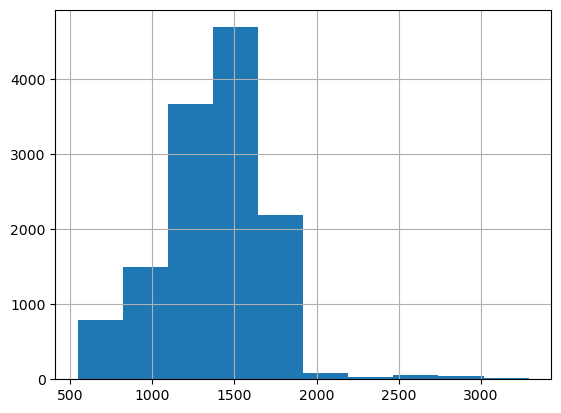

In [33]:
join.Prec_5.hist()

In [ ]:
join.Rate_20.max()

# Correlaciones

In [ ]:
join.columns

In [41]:
df=join[['Slope','Height', 'Aspect', 'Magnitude', 'NBR_pre_fire','NBR_post_fire', 'SPEI6_5', 'Prec_5', 'Tmin_5', 'Tmax_5', 'Rate_5']]
df.columns=['Slope','Elevation', 'Aspect', 'Magnitude', 'NBR pre fire','NBR post fire', 'SPEI6 5', 'Prec 5', 'Tmin 5', 'Tmax 5', 'Rate 5']


In [37]:
join

,Row,ID,NBR_pre_fire,NBR_post_fire,IDs,ID_forest,Magnitude,Severity,Slope,Aspect,...,latitude,longitude,Prec_5,Prec_20,Tmax_5,Tmax_20,Tmin_5,Tmin_20,SPEI6_5,SPEI6_20
0,[3693 6452],2769_C,0.619521,0.259847,[3693 6452]2769_C,2769378.0,-0.805990,High,9.249018,126.615660,...,42.004622,1.738914,1778.900034,7635.000118,21.076553,22.404897,11.145752,11.658660,-0.320980,-0.445321
1,[3836 5662],4186_C,0.702410,0.303376,[3836 5662]4186_C,4186124.0,-0.982603,High,10.739494,339.857180,...,41.966084,1.526013,1575.400035,5814.600116,22.826210,24.751893,12.476340,12.361343,-0.444222,-0.526123
2,[4775 8160],4060_C,0.751668,0.487907,[4775 8160]4060_C,4060379.0,-1.003493,High,16.414444,351.533940,...,41.713029,2.199211,1629.600034,6593.000115,22.326777,23.339992,12.913321,13.188058,-0.451335,-0.372742
3,[4748 8305],4060_C,0.565660,0.390595,[4748 8305]4060_C,4060379.0,-0.757767,High,39.558315,63.209900,...,41.720305,2.238287,1622.800019,6627.600158,22.926958,23.922328,13.347965,13.487526,-0.451335,-0.372742
4,[4601 9743],510_C,0.681981,0.504946,[4601 9743]510_C,51046.0,-0.905864,High,3.726514,221.787980,...,41.759921,2.625820,1310.400029,5589.400105,26.077072,26.462798,14.569105,14.711922,-0.442969,-0.417554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13038,[4891 3876],10680_V,0.544578,0.358693,[4891 3876]10680_V,1068024.0,-0.767129,High,28.986002,6.540445,...,39.681867,-0.955494,731.800018,3503.500061,26.584367,27.149373,13.689776,14.009868,-0.562988,-0.535502
13039,[4452 6012],4187_C,0.727112,0.455512,[4452 6012]4187_C,4187117.0,-0.547294,Mod_High,13.698620,258.507750,...,41.800075,1.620336,1447.600017,5330.000078,23.347490,25.261449,13.229114,12.999271,-0.467318,-0.478101
13040,[3864 6817],2769_C,0.550255,0.176978,[3864 6817]2769_C,2769379.0,-0.862050,High,12.017525,155.855560,...,41.958538,1.837279,1368.000027,5744.000095,23.549962,24.908179,13.343594,13.519167,-0.411849,-0.426257
13041,[5072 6764],22_C,0.578856,0.434014,[5072 6764]22_C,2224.0,-0.385421,Mod_Low,11.256167,347.429230,...,41.632989,1.822996,1369.300037,5477.400104,24.633316,24.675216,15.238118,15.216723,-0.327067,-0.344014


In [42]:
# os.chdir(r'C:\Users\giambelluca.144055\OneDrive\Doctorado\Articulos\Wildfire\Puntos\Filtro100_NBR04\Resultados_25032025\Imagenes')
os.chdir(r'C:\Users\giambelluca.144055\OneDrive\Doctorado\Articulos\Wildfire\Puntos\Filtro100_NBR04\Resultados_28032025')

In [35]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from matplotlib.colors import Normalize
from scipy.stats import gaussian_kde

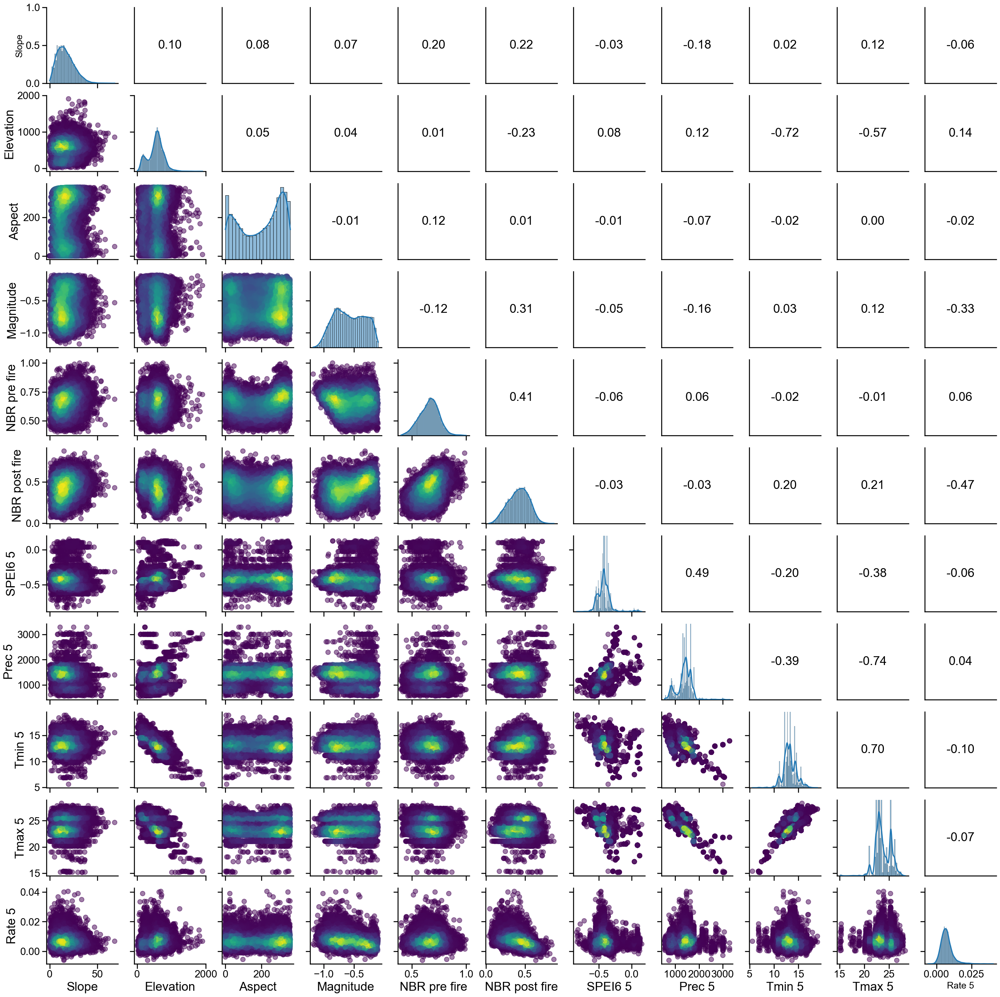

In [43]:
# Simulamos un DataFrame con 10 variables predictoras y 1 variable a predecir
np.random.seed(42)
data = df

def correlation_matrix(df, font_scale=1, value_fontsize=24, **kwargs):
    sns.set_context("talk", font_scale=font_scale)
    grid = sns.PairGrid(df, **kwargs)

    def hist_with_freq(x, **kwargs):
        sns.histplot(x, kde=True, **kwargs)
        ax = plt.gca()
        ax.set_ylabel("Frecuencia", fontsize=24) 
        ax.tick_params(axis='both', labelsize=20)  # Ajusta el tamaño de la fuente del nombre del eje y
        if ax.get_position().y0 <= 0.5:
            ax.set_ylim(bottom=0)

    def density_scatter_plot(x, y, **kwargs):
        values = np.vstack((x, y))
        kernel = gaussian_kde(values)
        kde = kernel.evaluate(values)
        norm = Normalize(vmin=kde.min(), vmax=kde.max())
        colors = cm.ScalarMappable(norm=norm, cmap='viridis').to_rgba(kde)
        kwargs['color'] = colors
        plt.xlabel(x.name, fontsize=24)  # Ajusta el tamaño de la fuente del nombre del eje x
        plt.ylabel(y.name, fontsize=24)  # Ajusta el tamaño de la fuente del nombre del eje y
        return plt.scatter(x, y, **kwargs)

    grid.map_lower(density_scatter_plot, alpha=0.5)
    grid.map_diag(hist_with_freq)

    def corr_coeff(x, y, **kwargs):
        corr = np.corrcoef(x, y)[0, 1]
        ax = plt.gca()
        ax.annotate(f"{corr:.2f}", xy=(0.5, 0.5), xycoords=ax.transAxes,
                    ha="center", va="center", fontsize=value_fontsize, color="black")

    grid.map_upper(corr_coeff)
    return grid

# Generar la visualización
g = correlation_matrix(data, font_scale=1, value_fontsize=24, corner=False)

for i, ax in enumerate(g.axes.flat):
    row = i // g.axes.shape[1]
    col = i % g.axes.shape[1]
    if row < col:
        ax.tick_params(bottom=False, left=False, labelsize=20)  # Ajusta el tamaño de la fuente de las etiquetas de los ticks
    else:
        ax.tick_params(axis='both', labelsize=20)  # Ajusta el tamaño de la fuente de las etiquetas de los ticks

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 24

plt.savefig(f"tasa5_ correlaciones.tiff", dpi=300, format="tiff")
# plt.show()

In [46]:
df=join[['Slope','Height', 'Aspect', 'Magnitude', 'NBR_pre_fire','NBR_post_fire', 'SPEI6_20', 'Prec_20', 'Tmin_20', 'Tmax_20', 'Rate_20']]
df.columns=['Slope','Elevation', 'Aspect', 'Magnitude', 'NBR pre fire','NBR post fire', 'SPEI6 20', 'Prec 20', 'Tmin 20', 'Tmax 20', 'Rate 20']


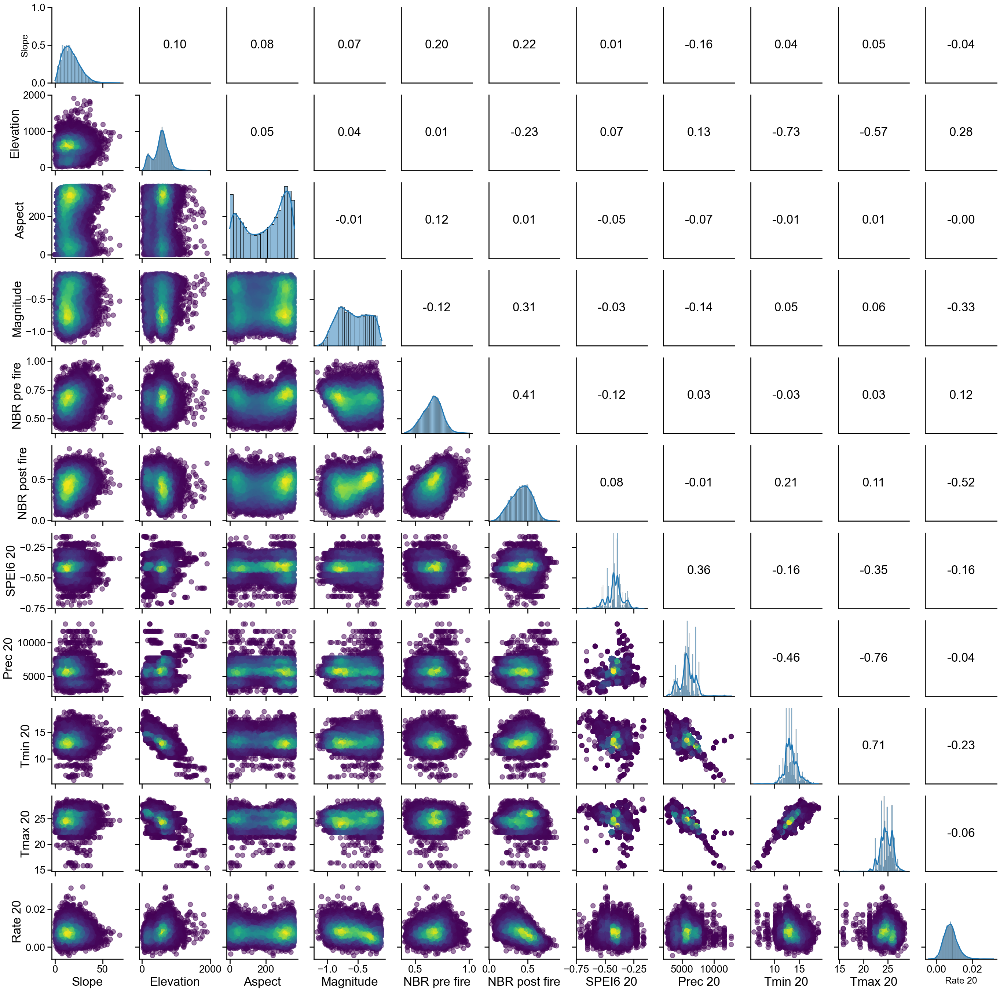

In [47]:
# Simulamos un DataFrame con 10 variables predictoras y 1 variable a predecir
np.random.seed(42)
data = df

# Función personalizada para agregar correlaciones
def correlation_matrix(df, font_scale=1, value_fontsize=24, **kwargs):
    sns.set_context("talk", font_scale=font_scale)
    grid = sns.PairGrid(df, **kwargs)

    def hist_with_freq(x, **kwargs):
        sns.histplot(x, kde=True, **kwargs)
        ax = plt.gca()
        ax.set_ylabel("Frecuencia", fontsize=24) 
        ax.tick_params(axis='both', labelsize=20)  # Ajusta el tamaño de la fuente del nombre del eje y
        if ax.get_position().y0 <= 0.5:
            ax.set_ylim(bottom=0)

    def density_scatter_plot(x, y, **kwargs):
        values = np.vstack((x, y))
        kernel = gaussian_kde(values)
        kde = kernel.evaluate(values)
        norm = Normalize(vmin=kde.min(), vmax=kde.max())
        colors = cm.ScalarMappable(norm=norm, cmap='viridis').to_rgba(kde)
        kwargs['color'] = colors
        plt.xlabel(x.name, fontsize=24)  # Ajusta el tamaño de la fuente del nombre del eje x
        plt.ylabel(y.name, fontsize=24)  # Ajusta el tamaño de la fuente del nombre del eje y
        return plt.scatter(x, y, **kwargs)

    grid.map_lower(density_scatter_plot, alpha=0.5)
    grid.map_diag(hist_with_freq)

    def corr_coeff(x, y, **kwargs):
        corr = np.corrcoef(x, y)[0, 1]
        ax = plt.gca()
        ax.annotate(f"{corr:.2f}", xy=(0.5, 0.5), xycoords=ax.transAxes,
                    ha="center", va="center", fontsize=value_fontsize, color="black")

    grid.map_upper(corr_coeff)
    return grid

# Generar la visualización
g = correlation_matrix(data, font_scale=1, value_fontsize=24, corner=False)

for i, ax in enumerate(g.axes.flat):
    row = i // g.axes.shape[1]
    col = i % g.axes.shape[1]
    if row < col:
        ax.tick_params(bottom=False, left=False, labelsize=20)  # Ajusta el tamaño de la fuente de las etiquetas de los ticks
    else:
        ax.tick_params(axis='both', labelsize=20)  # Ajusta el tamaño de la fuente de las etiquetas de los ticks

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 24

plt.savefig(f"tasa20_ correlaciones.tiff", dpi=300, format="tiff")

# Random Forest

In [48]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import make_regression
import numpy as np
from sklearn import metrics, model_selection
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error

In [49]:
join_r=join

In [50]:
join

,Row,ID,NBR_pre_fire,NBR_post_fire,IDs,ID_forest,Magnitude,Severity,Slope,Aspect,...,latitude,longitude,Prec_5,Prec_20,Tmax_5,Tmax_20,Tmin_5,Tmin_20,SPEI6_5,SPEI6_20
0,[3693 6452],2769_C,0.619521,0.259847,[3693 6452]2769_C,2769378.0,-0.805990,High,9.249018,126.615660,...,42.004622,1.738914,1778.900034,7635.000118,21.076553,22.404897,11.145752,11.658660,-0.320980,-0.445321
1,[3836 5662],4186_C,0.702410,0.303376,[3836 5662]4186_C,4186124.0,-0.982603,High,10.739494,339.857180,...,41.966084,1.526013,1575.400035,5814.600116,22.826210,24.751893,12.476340,12.361343,-0.444222,-0.526123
2,[4775 8160],4060_C,0.751668,0.487907,[4775 8160]4060_C,4060379.0,-1.003493,High,16.414444,351.533940,...,41.713029,2.199211,1629.600034,6593.000115,22.326777,23.339992,12.913321,13.188058,-0.451335,-0.372742
3,[4748 8305],4060_C,0.565660,0.390595,[4748 8305]4060_C,4060379.0,-0.757767,High,39.558315,63.209900,...,41.720305,2.238287,1622.800019,6627.600158,22.926958,23.922328,13.347965,13.487526,-0.451335,-0.372742
4,[4601 9743],510_C,0.681981,0.504946,[4601 9743]510_C,51046.0,-0.905864,High,3.726514,221.787980,...,41.759921,2.625820,1310.400029,5589.400105,26.077072,26.462798,14.569105,14.711922,-0.442969,-0.417554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13038,[4891 3876],10680_V,0.544578,0.358693,[4891 3876]10680_V,1068024.0,-0.767129,High,28.986002,6.540445,...,39.681867,-0.955494,731.800018,3503.500061,26.584367,27.149373,13.689776,14.009868,-0.562988,-0.535502
13039,[4452 6012],4187_C,0.727112,0.455512,[4452 6012]4187_C,4187117.0,-0.547294,Mod_High,13.698620,258.507750,...,41.800075,1.620336,1447.600017,5330.000078,23.347490,25.261449,13.229114,12.999271,-0.467318,-0.478101
13040,[3864 6817],2769_C,0.550255,0.176978,[3864 6817]2769_C,2769379.0,-0.862050,High,12.017525,155.855560,...,41.958538,1.837279,1368.000027,5744.000095,23.549962,24.908179,13.343594,13.519167,-0.411849,-0.426257
13041,[5072 6764],22_C,0.578856,0.434014,[5072 6764]22_C,2224.0,-0.385421,Mod_Low,11.256167,347.429230,...,41.632989,1.822996,1369.300037,5477.400104,24.633316,24.675216,15.238118,15.216723,-0.327067,-0.344014


In [ ]:
join_r.columns

In [51]:
join_r.loc[(join_r['Especie1']=='Quercus ilex'),['Sp_clas']]=[1]
join_r.loc[(join_r['Especie1']== 'Pinus halepensis'),['Sp_clas']]=[2]
join_r.loc[(join_r['Especie1']=='Quercus faginea'),['Sp_clas']]=[3]
join_r.loc[(join_r['Especie1']=='Pinus uncinata'),['Sp_clas']]=[4]
join_r.loc[(join_r['Especie1']=='Pinus pinaster'),['Sp_clas']]=[5]
join_r.loc[(join_r['Especie1']=='Pinus pinea'),['Sp_clas']]=[6]
join_r.loc[(join_r['Especie1']=='Pinus sylvestris'),['Sp_clas']]=[7]
join_r.loc[(join_r['Especie1']=='Quercus humilis (Q. Pubescens)'),['Sp_clas']]=[8]
join_r.loc[(join_r['Especie1']=='Quercus robur'),['Sp_clas']]=[9]
join_r.loc[(join_r['Especie1']=='Pinus radiata'),['Sp_clas']]=[10]
join_r.loc[(join_r['Especie1']=='Quercus suber'),['Sp_clas']]=[11]
join_r.loc[(join_r['Especie1']=='Pinus canariensis'),['Sp_clas']]=[12]
join_r.loc[(join_r['Especie1']=='Quercus rubra'),['Sp_clas']]=[13]
join_r.loc[(join_r['Especie1']=='Pinus nigra'),['Sp_clas']]=[14]

In [53]:
join.columns

Index(['Row', 'ID', 'NBR_pre_fire', 'NBR_post_fire', 'IDs', 'ID_forest',
       'Magnitude', 'Severity', 'Slope', 'Aspect', 'Face', 'TRSI', 'Height',
       'North', 'East', 'CCAA', 'Especie1', 'MFE_1985_R', 'FECHA', 'Label',
       'Range_S', 'Range_H', 'Rate_5', 'Rate_20', 'NBR_mean', 'latitude',
       'longitude', 'Prec_5', 'Prec_20', 'Tmax_5', 'Tmax_20', 'Tmin_5',
       'Tmin_20', 'SPEI6_5', 'SPEI6_20', 'Sp_clas'],
      dtype='object')

In [54]:
join_r.columns=['Row', 'ID', 'NBR_pre_fire', 'NBR_post_fire', 'IDs', 'ID_forest',
       'Magnitude', 'Severity', 'Slope', 'Aspect', 'Face', 'TRSI', 'Elevation',
       'North', 'East', 'CCAA', 'Especie1', 'MFE_1985_R', 'FECHA', 'Label',
       'Range_S', 'Range_H', 'Rate_5', 'Rate_20', 'NBR_mean', 'latitude',
       'longitude', 'Prec_5', 'Prec_20', 'Tmax_5', 'Tmax_20', 'Tmin_5',
       'Tmin_20', 'SPEI6_5', 'SPEI6_20', 'Species']

# join_r=join_r[['Row', 'ID', 'NBR_pre_fire', 'NBR_post_fire', 'IDs',
#        'ID_forest', 'Magnitude', 'Severity', 'Slope', 'Aspect', 'Face', 'TRSI',
#        'Elevation', 'North', 'East', 'CCAA', 'Especie1', 'MFE_1985_R', 'FECHA',
#        'Label', 'Range_S', 'Range_H', 'Rate_5', 'Rate_20', 'NBR_mean',
#        'latitude', 'longitude', 'Prec_5', 'Prec_20', 'Tmax_5', 'Tmax_20',
#        'Tmin_5', 'Tmin_20', 'SPEI6_5', 'SPEI6_20', 'Species']]

In [120]:
# Se fija la semilla de numpy para que la generación aleatoria siempre nos de los mismos números
np.random.seed(12)
# variables=['Slope','Elevation', 'Aspect', 'Magnitude', 'NBR_pre_fire','NBR_post_fire', 'SPEI6_5', 'Prec_5', 'Tmin_5', 'Tmax_5', 'Species']
variables=['Slope','Elevation', 'Aspect', 'Magnitude', 'NBR_pre_fire','NBR_post_fire',  'SPEI6_20','Prec_20', 'Tmin_20', 'Tmax_20', 'Species']
# Particionado de los datos en train y test
X_train, X_test, y_train, y_test = model_selection.train_test_split(join_r[variables], join_r['Rate_20'], train_size=0.7)
# LLamada al constructor del random forest utilizando 100 árboles base
RF = RandomForestRegressor(n_estimators=100, random_state=0)
# Entrenamiento del árbol de decisión
RF.fit(X_train, y_train)

RandomForestRegressor(random_state=0)

In [ ]:

# Se realizan las predicciones del árbol de decisión con los ejemplos de entrenamiento
predictionTrain = RF.predict(X_train)
predictionTest = RF.predict(X_test)
importancia=RF.feature_importances_.tolist()
for i in range(len(variables)):
    print(variables[i],': ',importancia[i])

y_pred = RF.predict(X_test)
custom_r2 = r2_score(y_test, y_pred)
print(' ')
print(' ')
print(f"R2 score (custom): {custom_r2}")
custom_rmse = mean_absolute_error(y_test, y_pred)
print(f"RMSE: {custom_rmse}")


Elevation :  0.09340081583552072
Aspect :  0.08717047064212805
Magnitude :  0.11492212247882158
NBR_pre_fire :  0.15871641132005995
NBR_post_fire :  0.3417359055403594
SPEI6_5 :  0.07849516306567704
Prec_5 :  0.03579826902205795
Tmin_5 :  0.0423636131799732
Tmax_5 :  0.030261094860396
Species :  0.017136134055006195
 
 
R2 score (custom): 0.4413473905746319
RMSE: 0.0021371358459771465


In [114]:
from sklearn.inspection import permutation_importance

In [121]:

r = permutation_importance(RF, X_test, y_test,
                           n_repeats=30,
                           random_state=0)

# for i in range(len(variables)):
#     print(variables[i],': ',importancia[i])

for i in r.importances_mean.argsort()[::-1]:
    # print(i)
    if r.importances_mean[i] - 2 * r.importances_std[i] > 0:
        print(f"{variables[i]:<8}"
              f"{r.importances_mean[i]:.3f}"
              f" +/- {r.importances_std[i]:.3f}")

NBR_post_fire0.954 +/- 0.028
NBR_pre_fire0.289 +/- 0.008
SPEI6_200.133 +/- 0.008
Prec_20 0.048 +/- 0.005
Elevation0.048 +/- 0.004
Magnitude0.035 +/- 0.003
Tmax_20 0.028 +/- 0.004
Tmin_20 0.022 +/- 0.002
Aspect  0.016 +/- 0.002
Species 0.012 +/- 0.002
Slope   0.005 +/- 0.002


# Dependencia parcial

In [122]:
from sklearn.inspection import PartialDependenceDisplay
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import itertools

In [123]:
join_r.FECHA

0        1994
1        1998
2        1994
3        1994
4        1994
         ... 
13038    1994
13039    1998
13040    1994
13041    1986
13042    1994
Name: FECHA, Length: 13043, dtype: int64

In [124]:
conversor=1/2.54

In [127]:
df=join_r[['Slope', 'Elevation', 'Aspect','Magnitude', 'SPEI6_5', 'Tmax_5', 'Tmin_5', 'Prec_5','NBR_pre_fire','NBR_post_fire','Species','Rate_5']]

c:\Users\giambelluca.144055\AppData\Local\anaconda3\envs\Wildfires\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


0
1
2
3
4
5
6
7
8
9
10


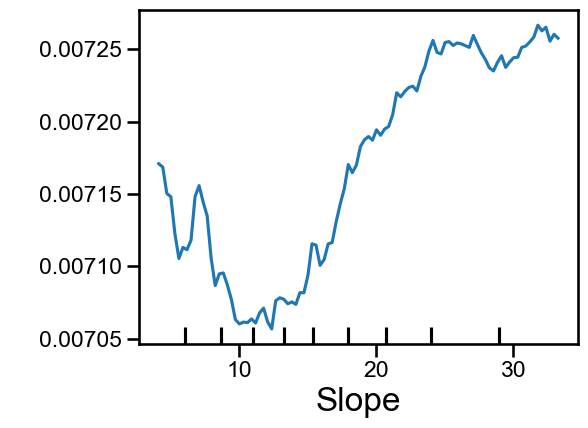

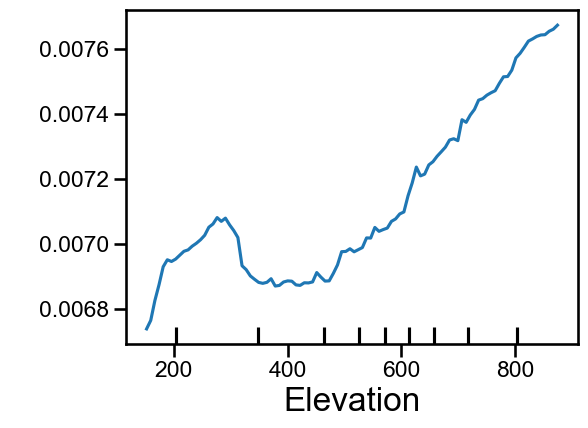

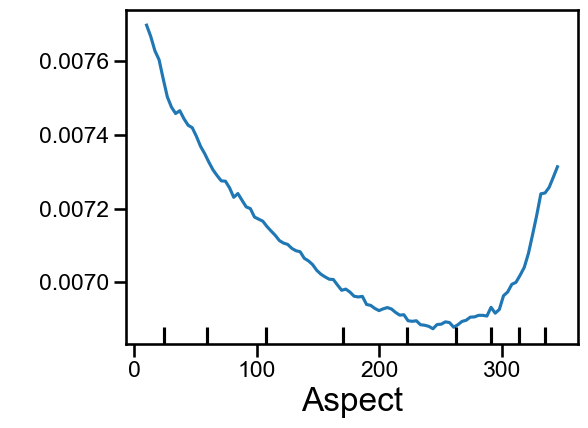

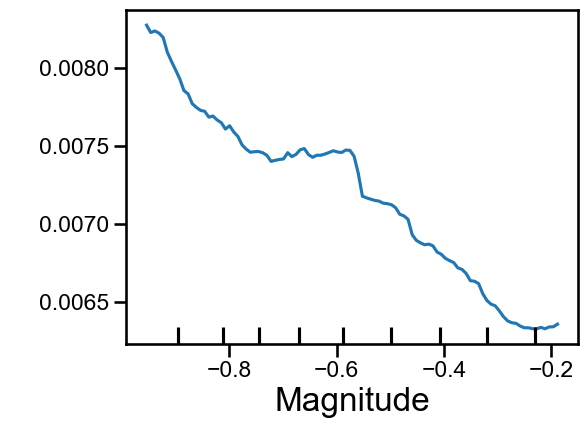

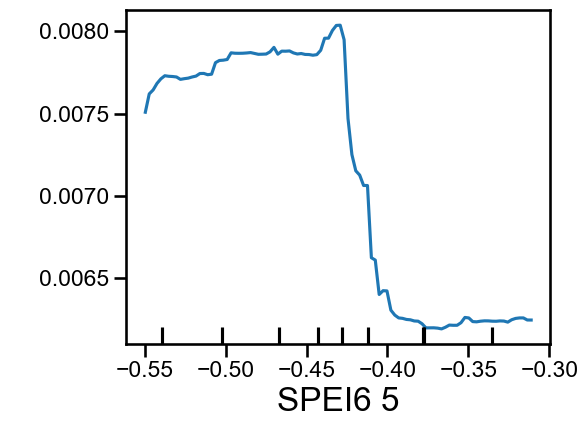

...

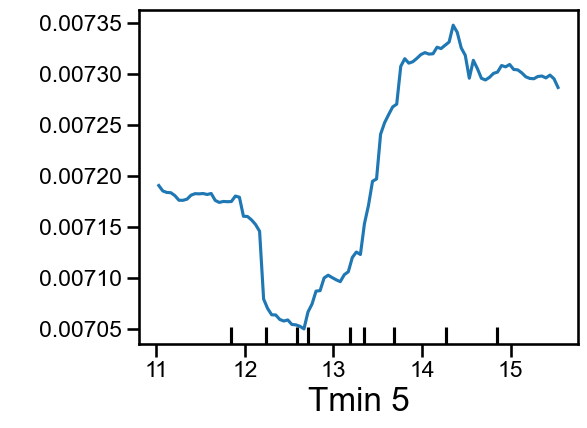

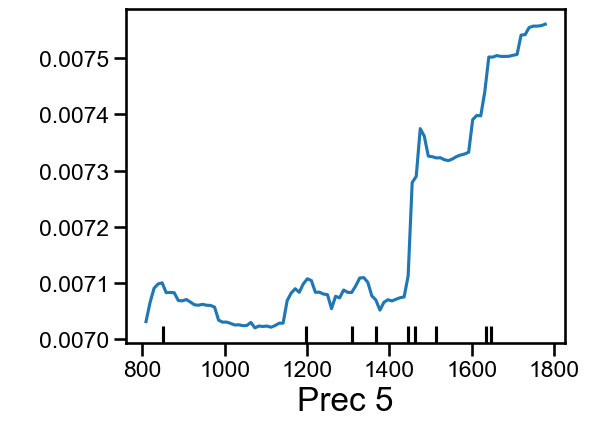

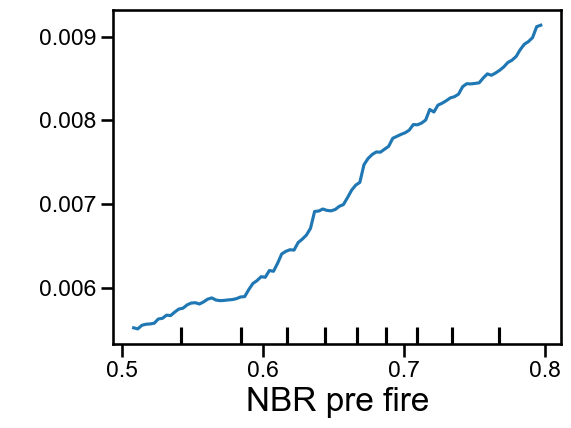

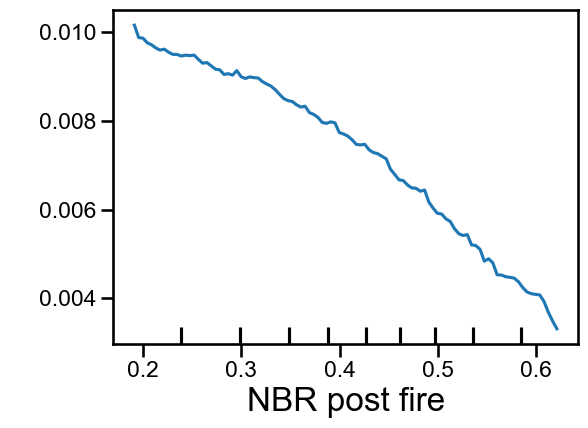

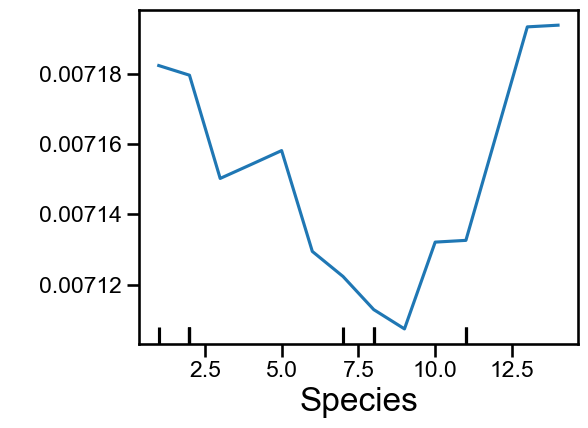

In [128]:
os.chdir(r'C:\Users\giambelluca.144055\OneDrive\Doctorado\Articulos\Wildfire\Puntos\Filtro100_NBR04\Resultados_28032025\PDP')
# Se fija la semilla de numpy para que la generación aleatoria siempre nos de los mismos números
np.random.seed(12)

# Definir las variables
variables = ['Slope', 'Elevation', 'Aspect','Magnitude', 'SPEI6 5', 'Tmax 5', 'Tmin 5', 'Prec 5','NBR pre fire','NBR post fire','Species']

# Suponiendo que join_r es tu dataset con todas las columnas
X = df[['Slope', 'Elevation', 'Aspect','Magnitude', 'SPEI6_5', 'Tmax_5', 'Tmin_5', 'Prec_5','NBR_pre_fire','NBR_post_fire','Species']]
y = df[['Rate_5']]

# Particionado de los datos en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=42)

# Crear un modelo Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=0)

# Entrenar el modelo
model.fit(X_train, y_train)
# features = variables
# X.columns
features = [0, 1, 2,3,4,5,6,7,8,9,10]
for i in range(0,11,1):
    print(i)
    PartialDependenceDisplay.from_estimator(model, X, [i])
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['font.size'] = 24
    plt.xlabel(variables[i], fontsize=24)  # Ajusta el tamaño de la fuente del nombre del eje x
    plt.ylabel(' ') 
    
    plt.tight_layout()
    plt.savefig(f"PDP_tasa5_{variables[i]}.tiff", dpi=300, format="tiff")
   
    # plt.tight_layout()

# for i, feature in enumerate(variables):
#         # fig, ax = plot_partial_dependence(model, feature)

#         PartialDependenceDisplay.from_estimator(
#                 model,
#                 X_train,
#                 [feature],
#                 grid_resolution=50,
#                 n_jobs=-1,
#                 # ax=ax
#                 # hist_kws={'density': True, 'color': 'skyblue'}
#             )

#         

In [129]:
df=join_r[['Slope', 'Elevation', 'Aspect','Magnitude', 'SPEI6_20', 'Tmax_20', 'Tmin_20', 'Prec_20','NBR_pre_fire','NBR_post_fire','Species','Rate_20']]
df

,Slope,Elevation,Aspect,Magnitude,SPEI6_20,Tmax_20,Tmin_20,Prec_20,NBR_pre_fire,NBR_post_fire,Species,Rate_20
0,9.249018,694.0,126.615660,-0.805990,-0.445321,22.404897,11.658660,7635.000118,0.619521,0.259847,8.0,0.007984
1,10.739494,695.0,339.857180,-0.982603,-0.526123,24.751893,12.361343,5814.600116,0.702410,0.303376,8.0,0.010531
2,16.414444,623.0,351.533940,-1.003493,-0.372742,23.339992,13.188058,6593.000115,0.751668,0.487907,1.0,0.010573
3,39.558315,725.0,63.209900,-0.757767,-0.372742,23.922328,13.487526,6627.600158,0.565660,0.390595,1.0,0.006907
4,3.726514,113.0,221.787980,-0.905864,-0.417554,26.462798,14.711922,5589.400105,0.681981,0.504946,11.0,0.005789
...,...,...,...,...,...,...,...,...,...,...,...,...
13038,28.986002,677.0,6.540445,-0.767129,-0.535502,27.149373,14.009868,3503.500061,0.544578,0.358693,2.0,0.007010
13039,13.698620,819.0,258.507750,-0.547294,-0.478101,25.261449,12.999271,5330.000078,0.727112,0.455512,3.0,0.006610
13040,12.017525,498.0,155.855560,-0.862050,-0.426257,24.908179,13.519167,5744.000095,0.550255,0.176978,1.0,0.015193
13041,11.256167,405.0,347.429230,-0.385421,-0.344014,24.675216,15.216723,5477.400104,0.578856,0.434014,2.0,0.006891


c:\Users\giambelluca.144055\AppData\Local\anaconda3\envs\Wildfires\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


0
1
2
3
4
5
6
7
8
9
10


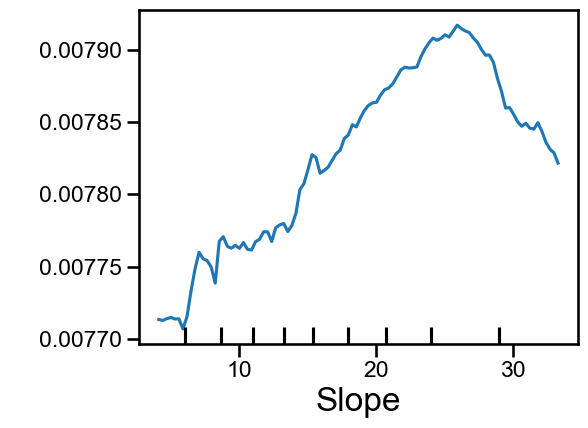

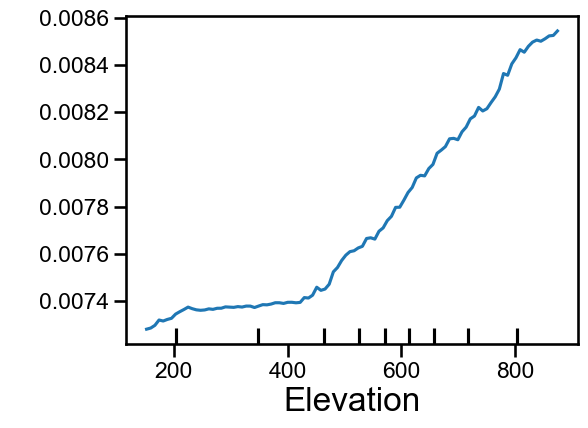

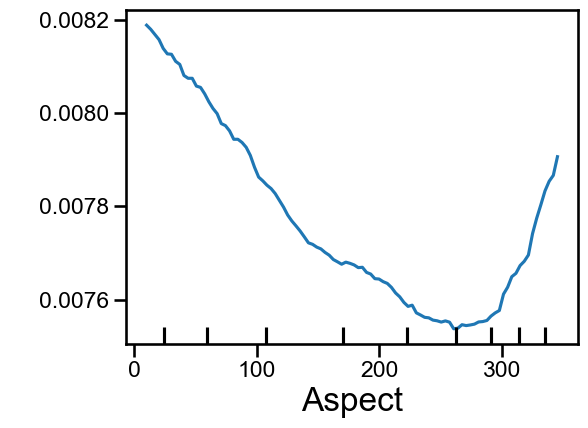

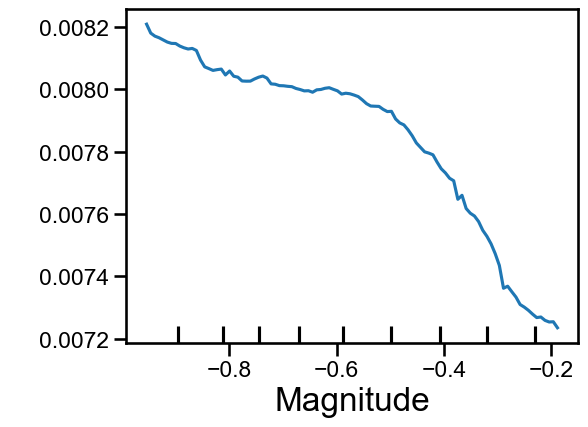

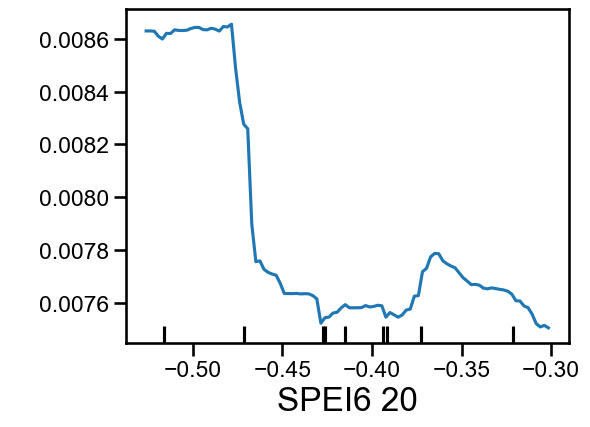

...

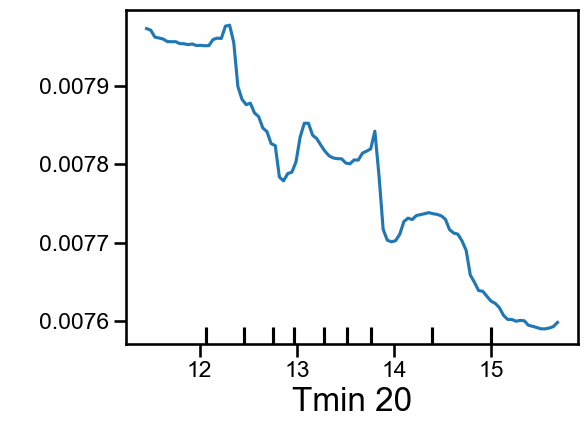

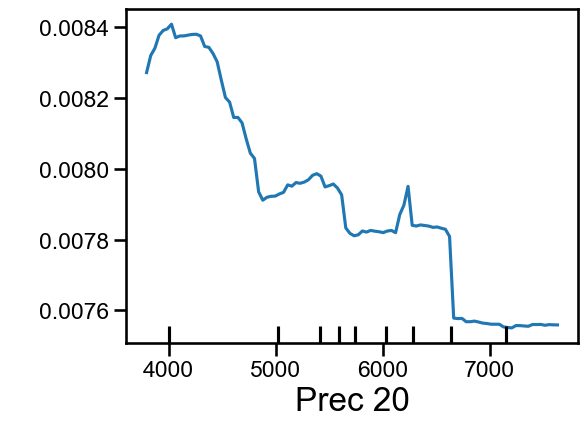

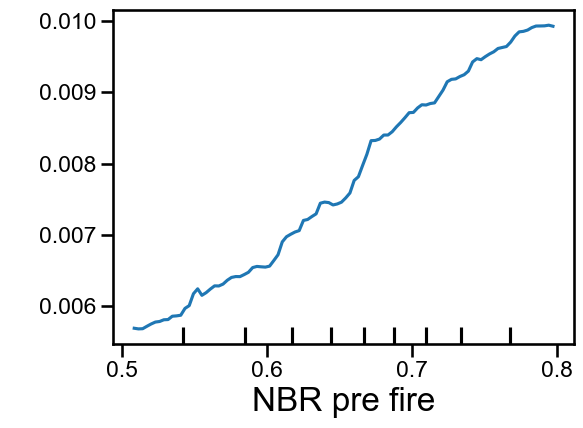

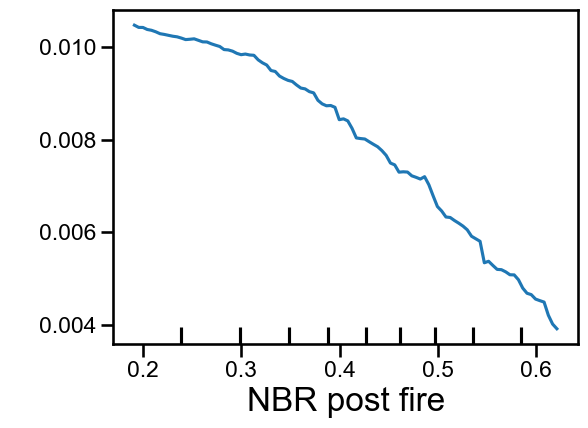

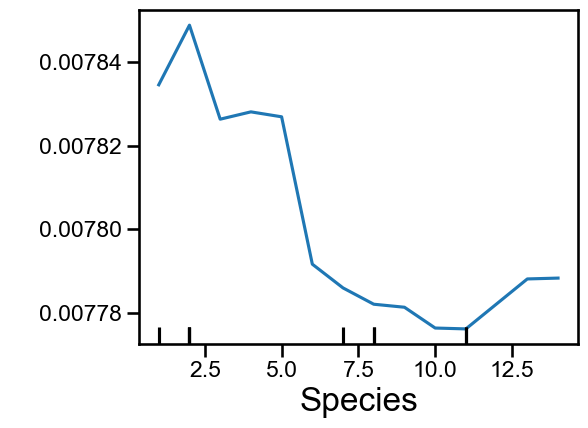

In [130]:
os.chdir(r'C:\Users\giambelluca.144055\OneDrive\Doctorado\Articulos\Wildfire\Puntos\Filtro100_NBR04\Resultados_28032025\PDP')
# Se fija la semilla de numpy para que la generación aleatoria siempre nos de los mismos números
np.random.seed(12)

# Definir las variables
variables = ['Slope', 'Elevation', 'Aspect','Magnitude', 'SPEI6 20', 'Tmax 20', 'Tmin 20', 'Prec 20','NBR pre fire','NBR post fire','Species']

# Suponiendo que join_r es tu dataset con todas las columnas
X = df[['Slope', 'Elevation', 'Aspect','Magnitude', 'SPEI6_20', 'Tmax_20', 'Tmin_20', 'Prec_20','NBR_pre_fire','NBR_post_fire','Species']]
y = df[['Rate_20']]

# Particionado de los datos en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=42)

# Crear un modelo Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=0)

# Entrenar el modelo
model.fit(X_train, y_train)
# features = variables
# X.columns
features = [0, 1, 2,3,4,5,6,7,8,9,10]
for i in range(0,11,1):
    print(i)
    PartialDependenceDisplay.from_estimator(model, X, [i])
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['font.size'] = 24
    plt.xlabel(variables[i], fontsize=24)  # Ajusta el tamaño de la fuente del nombre del eje x
    plt.ylabel(' ') 
    
    plt.tight_layout()
    plt.savefig(f"PDP_tasa20_{variables[i]}.tiff", dpi=300, format="tiff")

# Dependencia doble

In [ ]:
os.chdir(r'C:\Users\laugi\OneDrive_backup\3\OneDrive\Incendios\Organizacion\Resultados\Unido_Tasa5y20\Tasa_post_normalizado_30012025\PDP')
np.random.seed(12)

# Definir las variables
variables = ['Slope', 'Elevation', 'Aspect','Magnitude', 'SPEI6_5', 'Tmax_5', 'Tmin_5', 'Prec_5','NBR_pre_fire','NBR_post_fire','Species','Rate_5']

# Suponiendo que join_r es tu dataset con todas las columnas
X = join_r[variables]
y = join_r['Tasa_20']

# Particionado de los datos en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=42)

# Crear un modelo Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=0)

# Entrenar el modelo
model.fit(X_train, y_train)
features = variables


for feature2 in (feat):
    print(feature2)
    features_2d=[feature2]
    plt.figure(figsize=(8*conversor,8*conversor))

    PartialDependenceDisplay.from_estimator(model, X, features=features_2d, kind='average')
    CS = plt.gca().collections[0]  # Obtiene el conjunto de contornos del gráfico actual
    
    plt.clabel(CS, inline=False, fontsize=10, fmt='%.3f') 
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['font.size'] = 16
    plt.tight_layout()

,Slope
0,9.249018
1,9.063176
2,10.739494
3,16.361952
4,16.414444
...,...
14050,28.986002
14051,13.698620
14052,12.017525
14053,11.256167


In [136]:
data=join[['Slope', 'Elevation', 'Aspect','Magnitude', 'SPEI6 5', 'Tmax 5', 'Tmin 5', 'Prec 5','NBR pre fire','NBR post fire']]

KeyError: "['SPEI6 5', 'Tmax 5', 'Tmin 5', 'Prec 5', 'NBR pre fire', 'NBR post fire'] not in index"

In [ ]:
grid = sns.PairGrid(df, **kwargs)

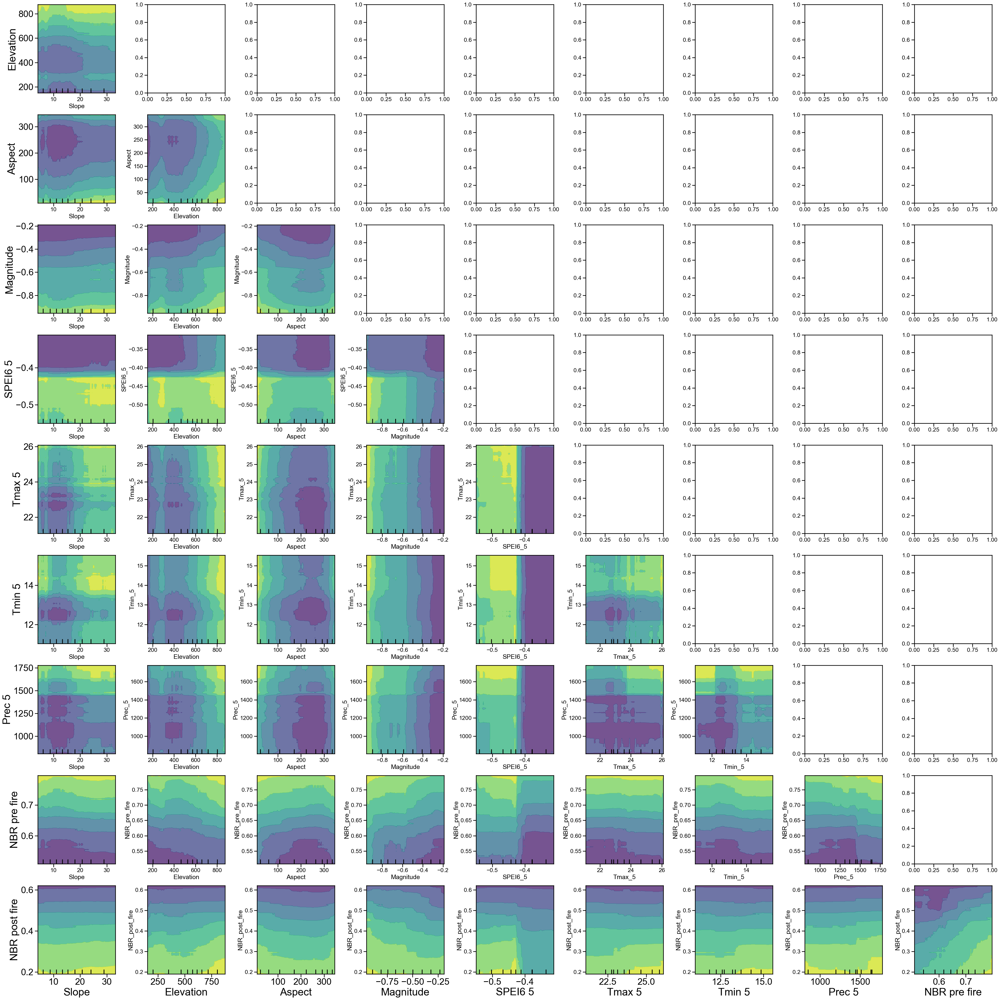

In [146]:
# os.chdir(r'C:\Users\laugi\OneDrive_backup\3\OneDrive\Incendios\Organizacion\Resultados\Unido_Tasa5y20\Tasa_post_normalizado_30012025\PDP')
np.random.seed(12)

# Definir las variables
variables = ['Slope', 'Elevation', 'Aspect','Magnitude', 'SPEI6_5', 'Tmax_5', 'Tmin_5', 'Prec_5','NBR_pre_fire','NBR_post_fire','Species']

# Suponiendo que join_r es tu dataset con todas las columnas
X = join_r[variables]
y = join_r['Rate_5']
var=['Slope', 'Elevation', 'Aspect','Magnitude', 'SPEI6 5', 'Tmax 5', 'Tmin 5', 'Prec 5','NBR pre fire','NBR post fire']
# Particionado de los datos en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=42)

# Crear un modelo Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=0)

# Entrenar el modelo
model.fit(X_train, y_train)
# features = variables

# fig, axes = plt.subplots(len(features), 1, figsize=(10, 5*len(features)))
# feat=[(0, 1),(0, 2),(0, 3),(0, 4),(0, 5),(0, 6),(0, 7),(0, 8),(0, 9),
#       (1, 2),(1, 3),(1, 4),(1, 5),(1, 6),(1, 7),(1, 8),(1, 9)
#       ,(2, 3),(2, 4),(2, 5),(2, 6),(2, 7),(2, 8),(2, 9)
#       ,(3, 4),(3, 5),(3, 6),(3, 7),(3, 8),(3, 9)
#       ,(4, 5),(4, 6),(4, 7),(4, 8),(4, 9)
#       ,(5, 6),(5, 7),(5, 8),(5, 9)
#       ,(6, 7),(6, 8),(6, 9)
#       ,(7, 8),(7, 9)
#       ,(8, 9)]

num_vars = len(var)
fig, axes = plt.subplots(num_vars - 1, num_vars - 1, figsize=(40, 40))

for i in range(num_vars - 1):
    for j in range(i + 1, num_vars):
        ax = axes[j - 1, i]  # Corrección en la indexación de los ejes
        features_2d = [(i, j)]
        display = PartialDependenceDisplay.from_estimator(model, X, features=features_2d, kind='average', ax=ax)

        for obj in display.axes_[0, 0].get_children():
            if isinstance(obj, plt.Text):
                obj.set_visible(False)
    # CS = plt.gca().collections[0].set_visible(False)  # Obtiene el conjunto de contornos del gráfico actual
        display.axes_[0, 0].collections[0].set_visible(False)
        # Mostrar solo las etiquetas de los ejes externos
        # if i == num_vars - 2:
        #     ax.set_xlabel(variables[i], fontsize=24, rotation=45, ha='right')
        # else:
        #     ax.set_xlabel('')

        # if j == i + 1:
        #     ax.set_ylabel(variables[j], fontsize=24)
        # else:
        #     ax.set_ylabel('')
                
        if j==9:
            plt.xlabel(var[i], fontsize=30)
            plt.tick_params(axis='x', labelsize=26)
            # ax.set_yticks(labels=[""])
            ax.yaxis.set_visible(False)
        if i==0:
            plt.ylabel(var[j], fontsize=30)
            plt.tick_params(axis='y', labelsize=26)
            # ax.set_xticks(labels=[""])
            ax.xaxis.set_visible(False)

        if j!=9 and i!=0:
            ax.xaxis.set_visible(False)
            ax.yaxis.set_visible(False)
            # ax.set_xticks(labels=[""])
            # ax.set_yticks(labels=[""])
        # ax.tick_params(axis='both', labelsize=20)
    # display.clabel(CS, inline=False, fontsize=10, fmt='%.3f') 
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 30
plt.tight_layout(pad=0.3)
        # plt.xlabel(variables[feature2[0]], fontsize=24)
        # plt.ylabel(variables[feature2[1]], fontsize=24)
# plt.tight_layout()
plt.show()









# for feature2 in (feat):
#     print(feature2)
#     features_2d=[feature2]
#     plt.figure(figsize=(8*conversor,8*conversor))

#     display=PartialDependenceDisplay.from_estimator(model, X, features=features_2d, kind='average')
#     for obj in display.axes_[0, 0].get_children():
#         if isinstance(obj, plt.Text):
#             obj.set_visible(False)
#     # CS = plt.gca().collections[0].set_visible(False)  # Obtiene el conjunto de contornos del gráfico actual
#     display.axes_[0, 0].collections[0].set_visible(False)
#     # display.clabel(CS, inline=False, fontsize=10, fmt='%.3f') 
#     plt.rcParams['font.family'] = 'Arial'
#     plt.rcParams['font.size'] = 16
#     plt.xlabel(variables[feature2[0]], fontsize=24)
#     plt.ylabel(variables[feature2[1]], fontsize=24)
#     plt.tight_layout()
#     plt.savefig(f"PDP_tasa20_{feature2[0]}_{feature2[1]}.tiff", dpi=300, format="tiff")
   
#     plt.show()

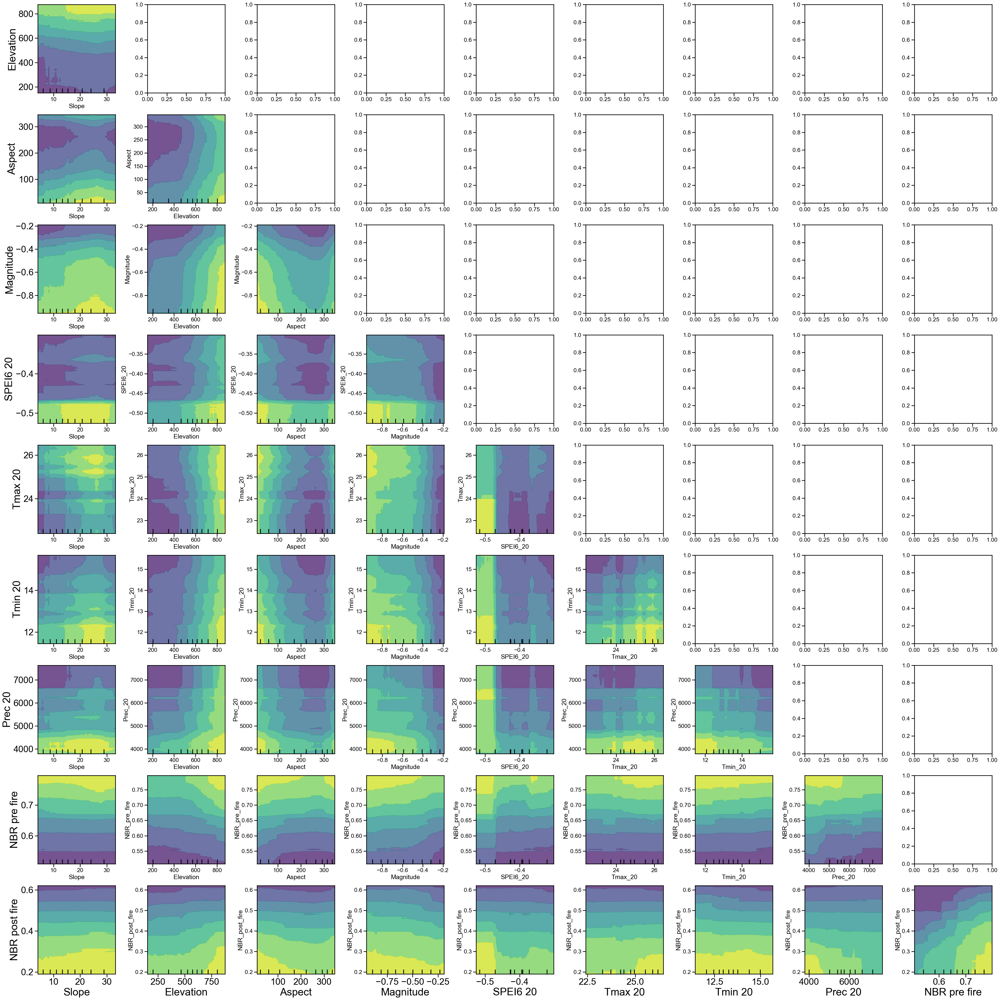

In [147]:
np.random.seed(12)

# Definir las variables
variables = ['Slope', 'Elevation', 'Aspect','Magnitude', 'SPEI6_20', 'Tmax_20', 'Tmin_20', 'Prec_20','NBR_pre_fire','NBR_post_fire','Species']

# Suponiendo que join_r es tu dataset con todas las columnas
X = join_r[variables]
y = join_r['Rate_20']
var=['Slope', 'Elevation', 'Aspect','Magnitude', 'SPEI6 20', 'Tmax 20', 'Tmin 20', 'Prec 20','NBR pre fire','NBR post fire']
# Particionado de los datos en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=42)

# Crear un modelo Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=0)

# Entrenar el modelo
model.fit(X_train, y_train)
# features = variables


num_vars = len(var)
fig, axes = plt.subplots(num_vars - 1, num_vars - 1, figsize=(40, 40))

for i in range(num_vars - 1):
    for j in range(i + 1, num_vars):
        ax = axes[j - 1, i]  # Corrección en la indexación de los ejes
        features_2d = [(i, j)]
        display = PartialDependenceDisplay.from_estimator(model, X, features=features_2d, kind='average', ax=ax)

        for obj in display.axes_[0, 0].get_children():
            if isinstance(obj, plt.Text):
                obj.set_visible(False)
    # CS = plt.gca().collections[0].set_visible(False)  # Obtiene el conjunto de contornos del gráfico actual
        display.axes_[0, 0].collections[0].set_visible(False)
        # Mostrar solo las etiquetas de los ejes externos
        # if i == num_vars - 2:
        #     ax.set_xlabel(variables[i], fontsize=24, rotation=45, ha='right')
        # else:
        #     ax.set_xlabel('')

        # if j == i + 1:
        #     ax.set_ylabel(variables[j], fontsize=24)
        # else:
        #     ax.set_ylabel('')
                
        if j==9:
            plt.xlabel(var[i], fontsize=30)
            plt.tick_params(axis='x', labelsize=26)
            # ax.set_yticks(labels=[""])
            ax.yaxis.set_visible(False)
        if i==0:
            plt.ylabel(var[j], fontsize=30)
            plt.tick_params(axis='y', labelsize=26)
            # ax.set_xticks(labels=[""])
            ax.xaxis.set_visible(False)

        if j!=9 and i!=0:
            ax.xaxis.set_visible(False)
            ax.yaxis.set_visible(False)
            # ax.set_xticks(labels=[""])
            # ax.set_yticks(labels=[""])
        # ax.tick_params(axis='both', labelsize=20)
    # display.clabel(CS, inline=False, fontsize=10, fmt='%.3f') 
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 30
plt.tight_layout(pad=0.3)
        # plt.xlabel(variables[feature2[0]], fontsize=24)
        # plt.ylabel(variables[feature2[1]], fontsize=24)
# plt.tight_layout()
plt.show()



In [ ]:
data=join_r[['Slope', 'Elevation', 'Aspect','Magnitude', 'SPEI6_5', 'Tmax_5', 'Tmin_5', 'Prec_5','NBR_pre_fire','NBR_post_fire','Species','Rate_5']].reset_index()
data

<method-wrapper '__getattribute__' of DataFrame object at 0x0000025E80744BF0>

# Diferencias significativas

In [252]:
var='Rate_20'

In [150]:
join_r.groupby('Especie1')['Row'].count()

Especie1
Pinus halepensis                  3815
Pinus nigra                       1153
Pinus pinaster                      98
Pinus pinea                         23
Pinus radiata                        4
Pinus sylvestris                   470
Pinus uncinata                       3
Quercus faginea                    413
Quercus humilis (Q. Pubescens)    2997
Quercus ilex                      2020
Quercus robur                        3
Quercus rubra                       30
Quercus suber                     2014
Name: Row, dtype: int64

In [268]:
species=join_r.loc[((join_r.Especie1=='Pinus nigra')|(join_r.Especie1=='Quercus suber')|(join_r.Especie1=='Quercus ilex')|(join_r.Especie1=='Quercus humilis (Q. Pubescens)')|(join_r.Especie1=='Pinus halepensis'))&(join_r.Severity=='Low')]
species

,Row,ID,NBR_pre_fire,NBR_post_fire,IDs,ID_forest,Magnitude,Severity,Slope,Aspect,...,Prec_5,Prec_20,Tmax_5,Tmax_20,Tmin_5,Tmin_20,SPEI6_5,SPEI6_20,Species,Abrev
36,[3087 4554],120_C,0.544264,0.487787,[3087 4554]120_C,12025.0,-0.224588,Low,28.075817,34.976100,...,2130.000032,8122.800127,20.318946,21.317509,9.798387,10.264445,0.086426,-0.270882,14.0,PN
42,[5048 3658],10680_V,0.676752,0.579930,[5048 3658]10680_V,10680378.0,-0.218616,Low,37.539340,47.613903,...,849.000015,3747.100070,25.381939,25.985888,11.848216,12.241249,-0.533350,-0.516182,1.0,HO
44,[3787 6031],10672_V,0.580690,0.456018,[3787 6031]10672_V,1067224.0,-0.188992,Low,34.997200,264.693480,...,775.200005,3940.100064,25.839851,26.167449,14.492768,14.992791,-0.563916,-0.571818,2.0,AP
54,[5301 7082],520_C,0.631324,0.419778,[5301 7082]520_C,520379.0,-0.247536,Low,19.777004,74.328610,...,1238.500019,5389.800064,24.636073,25.634603,15.703084,15.676711,-0.505501,-0.424581,8.0,DO
69,[3567 5655],10672_V,0.715228,0.654936,[3567 5655]10672_V,1067224.0,-0.136644,Low,16.858154,335.250640,...,845.400014,3941.100051,25.467111,25.823026,13.192182,13.646312,-0.539372,-0.471273,2.0,AP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13013,[3504 5823],10672_V,0.668373,0.543820,[3504 5823]10672_V,1067224.0,-0.228817,Low,23.861725,331.437770,...,845.400014,3941.100051,25.467111,25.823026,13.192182,13.646312,-0.539372,-0.471273,2.0,AP
13017,[4826 4358],369_N,0.673600,0.724275,[4826 4358]369_N,369335.0,-0.235201,Low,9.278411,187.748600,...,1414.800032,5436.500088,24.381888,24.833597,11.900427,12.393992,-0.125195,-0.373267,1.0,HO
13025,[4388 9853],510_C,0.778422,0.576295,[4388 9853]510_C,510115.0,-0.128987,Low,13.856632,10.143177,...,1634.700023,6502.100157,25.414802,26.166693,13.526614,13.755439,-0.442969,-0.417554,11.0,CO
13031,[3939 6903],595_C,0.808516,0.588804,[3939 6903]595_C,59525.0,-0.194370,Low,18.857637,18.576605,...,1368.000027,5744.000095,23.549962,24.908179,13.343594,13.519167,-0.411849,-0.426257,2.0,AP


In [228]:
species.groupby('Species')['Row'].count()

Species
1.0     1365
2.0      775
8.0     1929
11.0     981
14.0     123
Name: Row, dtype: int64

In [247]:
C1=species.loc[(species.Species==1)].sample(123,random_state=12)
C2=species.loc[(species.Species==2)].sample(123,random_state=12)
C3=species.loc[(species.Species==8)].sample(123,random_state=12)
C4=species.loc[(species.Species==14)].sample(123,random_state=12)
C5=species.loc[(species.Species==11)].sample(123,random_state=12)

specie=pd.concat([C1,C2,C3,C4,C5])

In [257]:
C1=species.loc[(species.Species==1)].sample(366,random_state=12)
C2=species.loc[(species.Species==2)].sample(366,random_state=12)
C3=species.loc[(species.Species==8)].sample(366,random_state=12)
C4=species.loc[(species.Species==14)].sample(366,random_state=12)
C5=species.loc[(species.Species==11)].sample(366,random_state=12)

specie=pd.concat([C1,C2,C3,C4,C5])

In [269]:
C1=species.loc[(species.Species==1)].sample(139,random_state=12)
C2=species.loc[(species.Species==2)].sample(139,random_state=12)
C3=species.loc[(species.Species==8)].sample(139,random_state=12)
C4=species.loc[(species.Species==14)].sample(139,random_state=12)
C5=species.loc[(species.Species==11)].sample(139,random_state=12)

specie=pd.concat([C1,C2,C3,C4,C5])

In [263]:
C1=species.loc[(species.Species==1)].sample(136,random_state=12)
C2=species.loc[(species.Species==2)].sample(136,random_state=12)
C3=species.loc[(species.Species==8)].sample(136,random_state=12)
C4=species.loc[(species.Species==14)].sample(136,random_state=12)
C5=species.loc[(species.Species==11)].sample(136,random_state=12)

specie=pd.concat([C1,C2,C3,C4,C5])

In [230]:
specie=pd.concat([high,MODHigh,MODLow,Low])

In [270]:
specie.loc[(specie['Especie1']=='Quercus ilex'),['Abrev']]=['HO']
specie.loc[(specie['Especie1']== 'Pinus halepensis'),['Abrev']]=['AP']
specie.loc[(specie['Especie1']=='Quercus humilis (Q. Pubescens)'),['Abrev']]=['DO']
specie.loc[(specie['Especie1']=='Quercus suber'),['Abrev']]=['CO']
specie.loc[(specie['Especie1']=='Pinus nigra'),['Abrev']]=['PN']

In [271]:
from scipy import stats
import statsmodels.formula.api as sfa
import scipy.stats as ss
import statsmodels.api as sa
# import scikit_posthocs as sp
# Al no respetarse la normalidad ni homocedisticidad se realiza el test de Kruskal Wallis
data = [specie.loc[ids,var].values for ids in specie.groupby('Especie1').groups.values()]



In [272]:
H, p = ss.kruskal(*data)
p

5.450695906213801e-16

In [273]:
e_type= specie.Especie1.unique()

ttests=[]


for i, e in enumerate(e_type):
	for i2,e2 in enumerate(e_type):
		if i2>i:
			g1=specie[specie.Especie1==e][var]
			g2=specie[specie.Especie1==e2][var]
			t,p=stats.ttest_ind(g1,g2)

			ttests.append([f'{e} - {e2}:', t.round(4),p.round(4)])

textstr=f'Sig. comparisons (Bonferroni)\n'

threshold=0.05/len(ttests)

print(f'Kruskal test: p-val {p.round(4)}, H: {H.round(4)} ', var)

print(textstr)
print(f'Significant t-tests below {threshold}:')

for t in ttests:
	if t[2] <= threshold:
		textstr2=f'{t[0]} {t[1]} {t[2]}'
		print(textstr2)

Kruskal test: p-val 0.0214, H: 77.6605  Rate_20
Sig. comparisons (Bonferroni)

Significant t-tests below 0.005:
Quercus ilex - Pinus halepensis: 3.0964 0.0022
Quercus ilex - Quercus humilis (Q. Pubescens): -5.3702 0.0
Pinus halepensis - Quercus humilis (Q. Pubescens): -8.377 0.0
Pinus halepensis - Quercus suber: -3.0576 0.0025
Quercus humilis (Q. Pubescens) - Pinus nigra: 7.5188 0.0
Quercus humilis (Q. Pubescens) - Quercus suber: 5.9981 0.0


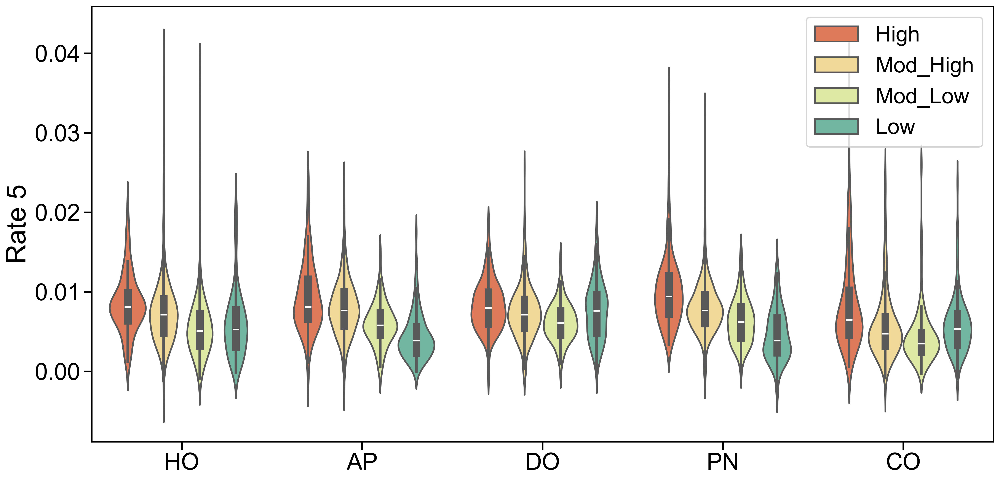

In [245]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_agg import FigureCanvasAgg

# Configurar el figure canvas
fig, ax = plt.subplots(figsize=(16, 8))
canvas = FigureCanvasAgg(fig)

PH=specie.loc[(specie.Especie1=='Pinus halepensis')]
QH=specie.loc[(specie.Especie1=='Quercus humilis (Q. Pubescens)')]
PN=specie.loc[(specie.Especie1=='Pinus nigra')]
QI=specie.loc[(specie.Especie1=='Quercus ilex')]
QS=specie.loc[(specie.Especie1=='Quercus suber')]

# Preparar los datos
array_ph = np.array(list(PH[var]))
array_qh = np.array(list(QH[var]))
array_pn = np.array(list(PN[var]))
array_qi = np.array(list(QI[var]))
array_qs = np.array(list(QS[var]))
# data = [array_n,array_e,array_p]
data = [array_ph,array_qh,array_pn,array_qi,array_qs]

# Crear el gráfico de cajas
# ax.boxplot(data, labels=['N', 'E', 'P'], showfliers=False)
# ax.boxplot(data, labels=['AP', 'DO','BP','HO','CO'], showfliers=False)
# sns.violinplot(data=specie, x="Abrev", y="Rate_5",color='#fcbf49')
sns.violinplot(data=specie, x="Abrev", y="Rate_5",hue='Severity', palette="Spectral")
# ax.set_ylabel('Rate 5')
plt.ylabel('Rate 5', fontsize=30)
plt.xlabel('', fontsize=30)

# Optimizar el rendimiento
fig.set_dpi(300)

# Personalizar el gráfico
plt.tick_params(axis='both', labelsize=26)
# ax.yaxis.grid(alpha=0.7)
plt.xticks(rotation=0)
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 26
# Mostrar el gráfico
plt.legend(fontsize=24,loc="upper right")
plt.tight_layout()
plt.show()